In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import math

import warnings
warnings.filterwarnings('ignore')

import sklearn
import scipy
import statsmodels.api as sm 
from scipy.stats import shapiro

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler


from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV


from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier


from sklearn.metrics import auc, roc_curve, roc_auc_score
from collections import Counter

In [2]:
application = pd.read_csv(r'H:\ES\SHB\home-credit-default-risk\application_train.csv')

In [3]:
bureau_balance = pd.read_csv(r'H:\ES\SHB\home-credit-default-risk\bureau_balance.csv')
bureau = pd.read_csv(r'H:\ES\SHB\home-credit-default-risk\bureau.csv')

In [4]:
credit_card_balance = pd.read_csv(r'H:\ES\SHB\home-credit-default-risk\credit_card_balance.csv')
pos_cash_balance = pd.read_csv(r'H:\ES\SHB\home-credit-default-risk\POS_CASH_balance.csv')

In [5]:
installments_payments = pd.read_csv(r'H:\ES\SHB\home-credit-default-risk\installments_payments.csv')
prev_application = pd.read_csv(r'H:\ES\SHB\home-credit-default-risk\previous_application.csv')

## About HC 
Home Credit strives to broaden financial inclusion for the unbanked population by providing a positive and safe borrowing experience. In order to make sure this underserved population has a positive loan experience, Home Credit makes use of a variety of alternative data--including telco and transactional information--to predict their clients' repayment abilities.

While Home Credit is currently using various statistical and machine learning methods to make these predictions, they're challenging Kagglers to help them unlock the full potential of their data. Doing so will ensure that clients capable of repayment are not rejected and that loans are given with a principal, maturity, and repayment calendar that will empower their clients to be successful.

## Data Model

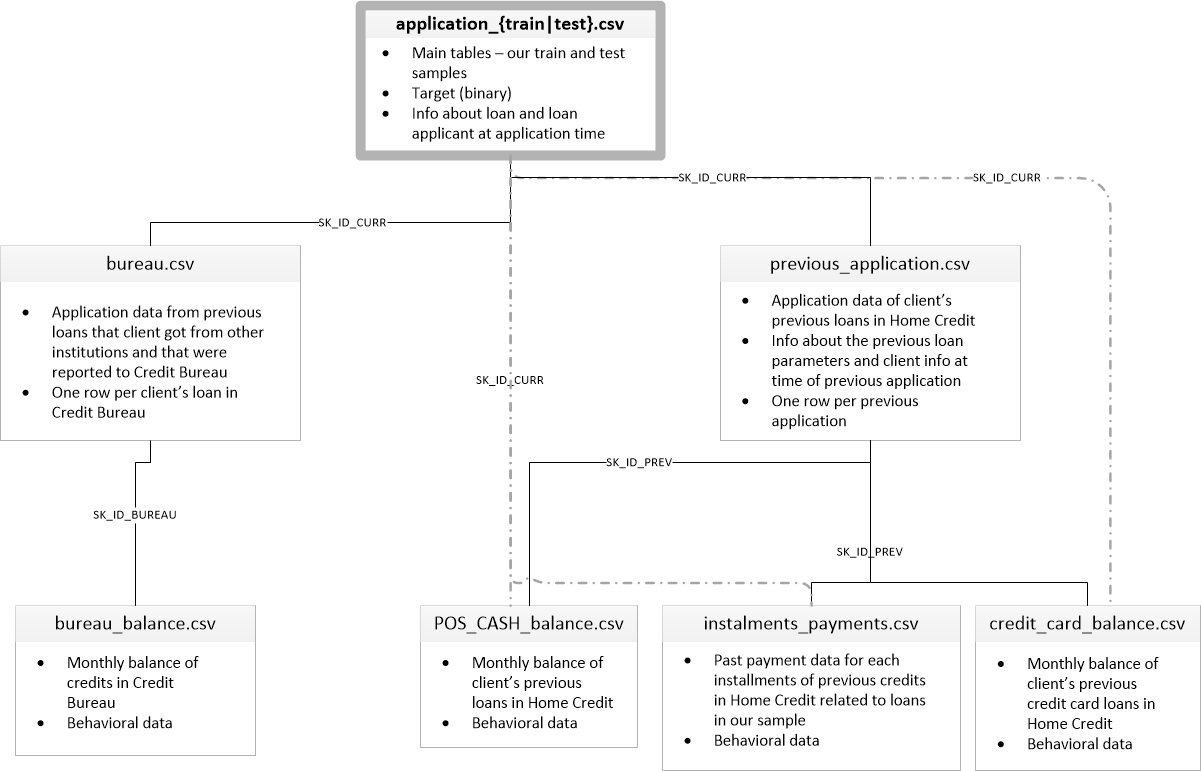

## Take a glimpse at the data

In [6]:
info = [
    ["application_train", application.shape[0], application.shape[1]],
    ["bureau", bureau.shape[0], bureau.shape[1]],
    ["bureau_balance", bureau_balance.shape[0], bureau_balance.shape[1]],
    ["credit_card_balance", credit_card_balance.shape[0], credit_card_balance.shape[1]],
    ["installments_payments", installments_payments.shape[0], installments_payments.shape[1]],
    ["previous_application", prev_application.shape[0], prev_application.shape[1]],
    ["POS_CASH_balance", pos_cash_balance.shape[0], pos_cash_balance.shape[1]]
]

data_info = pd.DataFrame(info, columns=["Dataset Name", "Rows", "Columns"])
data_info

,Dataset Name,Rows,Columns
0,application_train,307511,122
1,bureau,1716428,17
2,bureau_balance,27299925,3
3,credit_card_balance,3840312,23
4,installments_payments,13605401,8
5,previous_application,1670214,37
6,POS_CASH_balance,10001358,8


## Missing data check

In [7]:
def missing_data(data):
    total = data.isnull().sum().sort_values(ascending = False)
    percent = (data.isnull().sum()/len(data)*100).sort_values(ascending = False)
    return pd.concat([total, percent], axis=1, keys=  ['Total', 'Percent'])

In [8]:
missing_data(application).head(10)

,Total,Percent
COMMONAREA_MEDI,214865,69.872297
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,214865,69.872297
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_MODE,210199,68.354953
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953


In [9]:
missing_data(bureau).head(10)

,Total,Percent
AMT_ANNUITY,1226791,71.473490
AMT_CREDIT_MAX_OVERDUE,1124488,65.513264
DAYS_ENDDATE_FACT,633653,36.916958
AMT_CREDIT_SUM_LIMIT,591780,34.477415
AMT_CREDIT_SUM_DEBT,257669,15.011932
DAYS_CREDIT_ENDDATE,105553,6.149573
AMT_CREDIT_SUM,13,0.000757
CREDIT_ACTIVE,0,0.000000
CREDIT_CURRENCY,0,0.000000
DAYS_CREDIT,0,0.000000


In [10]:
missing_data(bureau_balance)

,Total,Percent
SK_ID_BUREAU,0,0.0
MONTHS_BALANCE,0,0.0
STATUS,0,0.0


In [11]:
missing_data(credit_card_balance).head(10)

,Total,Percent
AMT_PAYMENT_CURRENT,767988,19.998063
AMT_DRAWINGS_ATM_CURRENT,749816,19.524872
CNT_DRAWINGS_POS_CURRENT,749816,19.524872
AMT_DRAWINGS_OTHER_CURRENT,749816,19.524872
AMT_DRAWINGS_POS_CURRENT,749816,19.524872
CNT_DRAWINGS_OTHER_CURRENT,749816,19.524872
CNT_DRAWINGS_ATM_CURRENT,749816,19.524872
CNT_INSTALMENT_MATURE_CUM,305236,7.948208
AMT_INST_MIN_REGULARITY,305236,7.948208
SK_ID_PREV,0,0.000000


In [12]:
missing_data(installments_payments).head(2)

,Total,Percent
DAYS_ENTRY_PAYMENT,2905,0.021352
AMT_PAYMENT,2905,0.021352


In [13]:
missing_data(prev_application).head(15)

,Total,Percent
RATE_INTEREST_PRIVILEGED,1664263,99.643698
RATE_INTEREST_PRIMARY,1664263,99.643698
AMT_DOWN_PAYMENT,895844,53.636480
RATE_DOWN_PAYMENT,895844,53.636480
NAME_TYPE_SUITE,820405,49.119754
NFLAG_INSURED_ON_APPROVAL,673065,40.298129
DAYS_TERMINATION,673065,40.298129
DAYS_LAST_DUE,673065,40.298129
DAYS_LAST_DUE_1ST_VERSION,673065,40.298129
DAYS_FIRST_DUE,673065,40.298129


In [14]:
missing_data(pos_cash_balance).head(2)

,Total,Percent
CNT_INSTALMENT_FUTURE,26087,0.260835
CNT_INSTALMENT,26071,0.260675


## Check Imbalance

In [15]:
temp = application["TARGET"].value_counts()
df = pd.DataFrame({'labels': temp.index,
                   'values': temp.values
                  })

fig = px.pie(
    df, 
    names='labels', 
    values='values',
    title='TARGET - Train Dataset'
)

fig.update_traces(textposition='inside' #, textinfo='percent+label'
                  )
fig.show()

## Exploratory data

In [16]:
def plot_stats(feature, horizontal_layout=True):
    # Value counts and sort descending
    temp = application[feature].value_counts().sort_values(ascending=False)
    df1 = pd.DataFrame({feature: temp.index, 'Number of contracts': temp.values})

    # Calculate the percentage of target=1 per category value
    cat_perc = application[[feature, 'TARGET']].groupby([feature], as_index=False).mean()
    cat_perc.sort_values(by='TARGET', ascending=False, inplace=True)

    # Setup subplot
    if horizontal_layout:
        specs = [[{"type": "bar"}, {"type": "bar"}]]
        rows, cols = 1, 2
        subplot_titles = ('Number of Contracts', 'Percent of Target = 1')
        fig = make_subplots(rows=rows, cols=cols, specs=specs, subplot_titles=subplot_titles, horizontal_spacing=0.2)
    else:
        specs = [[{"type": "bar"}], [{"type": "bar"}]]
        rows, cols = 2, 1
        subplot_titles = ('Number of Contracts', 'Percent of Target = 1')
        fig = make_subplots(rows=rows, cols=cols, specs=specs, subplot_titles=subplot_titles, vertical_spacing=0.2)

    # First bar (Number of contracts) - sort descending
    fig.add_trace(
        go.Bar(
            y=df1.sort_values('Number of contracts', ascending=True)[feature],  # ascending=True vì y trên plotly sẽ đi từ dưới lên
            x=df1.sort_values('Number of contracts', ascending=True)['Number of contracts'],
            orientation='h',
        ),
        row=1, col=1
    )

    # Second bar (Percent target = 1) - sort descending
    fig.add_trace(
        go.Bar(
            y=cat_perc.sort_values('TARGET', ascending=True)[feature],  # ascending=True để bar dài nhất ở trên cùng
            x=cat_perc.sort_values('TARGET', ascending=True)['TARGET'] * 100,
            orientation='h',
        ),
        row=1 if horizontal_layout else 2, 
        col=2 if horizontal_layout else 1
    )

    fig.update_layout(
        height=600 if horizontal_layout else 900,
        width=1000,
        showlegend=False,
        title_text=f"Feature: {feature}",
        template="plotly_white"
    )

    fig.update_xaxes(title_text="Number of Contracts", row=1, col=1)
    fig.update_xaxes(title_text="Percent of Target = 1 (%)", row=1 if horizontal_layout else 2, col=2 if horizontal_layout else 1)

    fig.show()

### Applications
**Loan types**

Let's see the type of the loans taken and also, on a separate plot, the percent of the loans (by type of the loan) with TARGET value 1 (not returned loan).

In [17]:
plot_stats('NAME_CONTRACT_TYPE')

There are two types of contracts in the dataset: revolving loans and cash loans. Revolving loans account for only about 10% of the total number of loans issued. However, the proportion of loans with the target label = 1 is approximately 5.5% for revolving loans, quite high compared to over 8% for cash loans.

**Client gender**

Let's see the gender of the clients and also, on a separate plot, the percent of the loans (by client gender) with TARGET value 1 (not returned loan).

In [18]:
plot_stats('CODE_GENDER')

The proportion of female customers is twice that of male customers. However, the rate of target = 1 among male customers is 1.5 times higher than that of female customers (10% vs. 6%)

In [19]:
plot_stats('FLAG_OWN_CAR')
plot_stats('FLAG_OWN_REALTY')

The number of customers without a car is approximately twice the number of those who own a car. In contrast, the number of customers who own real estate is about twice the number of those who do not. Despite these differences in asset ownership, the default rate across all groups remains relatively stable, fluctuating slightly around 8%.

**Family status of client**

In [21]:
plot_stats('NAME_FAMILY_STATUS', True)

Nearly two-thirds of customers are married, but the highest proportion of target = 1 is found among customers in civil marriages and those who are single or not married, with a rate of nearly 10%.

**Number of children**

In [ ]:
plot_stats('CNT_CHILDREN')

The majority of customers do not have children, while the remaining customers have between 1 and 3 children. The likelihood of having target = 1 increases with the number of children.

**Number of family members of client**

In [ ]:
plot_stats('CNT_FAM_MEMBERS',True)

The majority of families consist of two members. However, the likelihood of default increases with the number of family members.

**Income type of client**

In [ ]:
plot_stats('NAME_INCOME_TYPE',False)

The majority of loan applicants have income from employment, followed by commercial associates, pensioners, and state servants.
Applicants with income from maternity leave have the highest non-repayment rate, at nearly 40%, followed by unemployed applicants at 37%. All other income types have a non-repayment rate of under 10%.

**Ocupation of client**

In [ ]:
plot_stats('OCCUPATION_TYPE',False)

The majority of loan applicants are laborers, sales staff, and core staff.
The default rate is highest among low-skilled occupations, including low-skilled laborers, drivers, waiters, security staff, and cooking staff, with rates exceeding 10%.

**Organization type**

In [ ]:
plot_stats('ORGANIZATION_TYPE', True)

Oraganizations with highest percent of loans not repaid are Transport: type 3 (16%), Industry: type 13 (13.5%), Industry: type 8 (12.5%) and Restaurant (less than 12%).

**Education type of the client**

In [ ]:
plot_stats('NAME_EDUCATION_TYPE',True)

The group receiving the most loans is those with a secondary school education, making up three-quarters of the total customer base. The target = 1 rate is also higher among groups with lower levels of education.

**Type of the housing of client**

In [ ]:
plot_stats('NAME_HOUSING_TYPE',True)

Most customers live in houses or apartments. However, the highest default rate is found among those living in rented apartments or with their parents.

### Distribution

In [24]:
# Plot distribution of one feature
def plot_distributions(features):
    num_plots = len(features)
    num_cols = 3
    num_rows = (num_plots + num_cols - 1) // num_cols  # Tự động tính số hàng

    plt.figure(figsize=(num_cols * 6, num_rows * 4))

    for idx, feature in enumerate(features):
        plt.subplot(num_rows, num_cols, idx + 1)
        plt.title(f"Distribution of {feature}")
        sns.histplot(application[feature].dropna(), kde=True, bins=100)
        plt.ylabel('')
        plt.tight_layout()

    plt.show()


'''
def plot_distributions(features):
    num_plots = len(features)
    num_cols = 3
    num_rows = (num_plots + num_cols - 1) // num_cols  # Automatically calculate number of rows
    
    for idx, feature in enumerate(features):
        # Create a histogram using plotly express
        fig = px.histogram(application, x=feature, nbins=100, title=f"Distribution of {feature}")
        fig.update_traces(opacity=0.75, marker=dict(line=dict(width=1, color='black')))
        fig.update_layout(
            showlegend=False,
            xaxis_title=feature,
            yaxis_title="Count",
            template="plotly_white"
        )
        fig.show()
'''

'\ndef plot_distributions(features):\n    num_plots = len(features)\n    num_cols = 3\n    num_rows = (num_plots + num_cols - 1) // num_cols  # Automatically calculate number of rows\n    \n    for idx, feature in enumerate(features):\n        # Create a histogram using plotly express\n        fig = px.histogram(application, x=feature, nbins=100, title=f"Distribution of {feature}")\n        fig.update_traces(opacity=0.75, marker=dict(line=dict(width=1, color=\'black\')))\n        fig.update_layout(\n            showlegend=False,\n            xaxis_title=feature,\n            yaxis_title="Count",\n            template="plotly_white"\n        )\n        fig.show()\n'

In [25]:
# Plot distribution of multiple features, with TARGET = 1/0 on the same graph
def plot_distribution_comp(var,nrow=2):
    
    i = 0
    t1 = application.loc[application['TARGET'] != 0]
    t0 = application.loc[application['TARGET'] == 0]

    sns.set_style('whitegrid')
    plt.figure()
    fig, ax = plt.subplots(nrow,figsize=(18,4*nrow))

    for feature in var:
        i += 1
        plt.subplot(nrow,3,i)
        sns.kdeplot(t1[feature], bw=0.5,label="TARGET = 1")
        sns.kdeplot(t0[feature], bw=0.5,label="TARGET = 0")
        plt.ylabel('Density plot', fontsize=12)
        plt.xlabel(feature, fontsize=12)
        locs, labels = plt.xticks()
        plt.tick_params(axis='both', which='major', labelsize=12)
    plt.show()

**Total income distribution**

In [26]:
cols = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH']

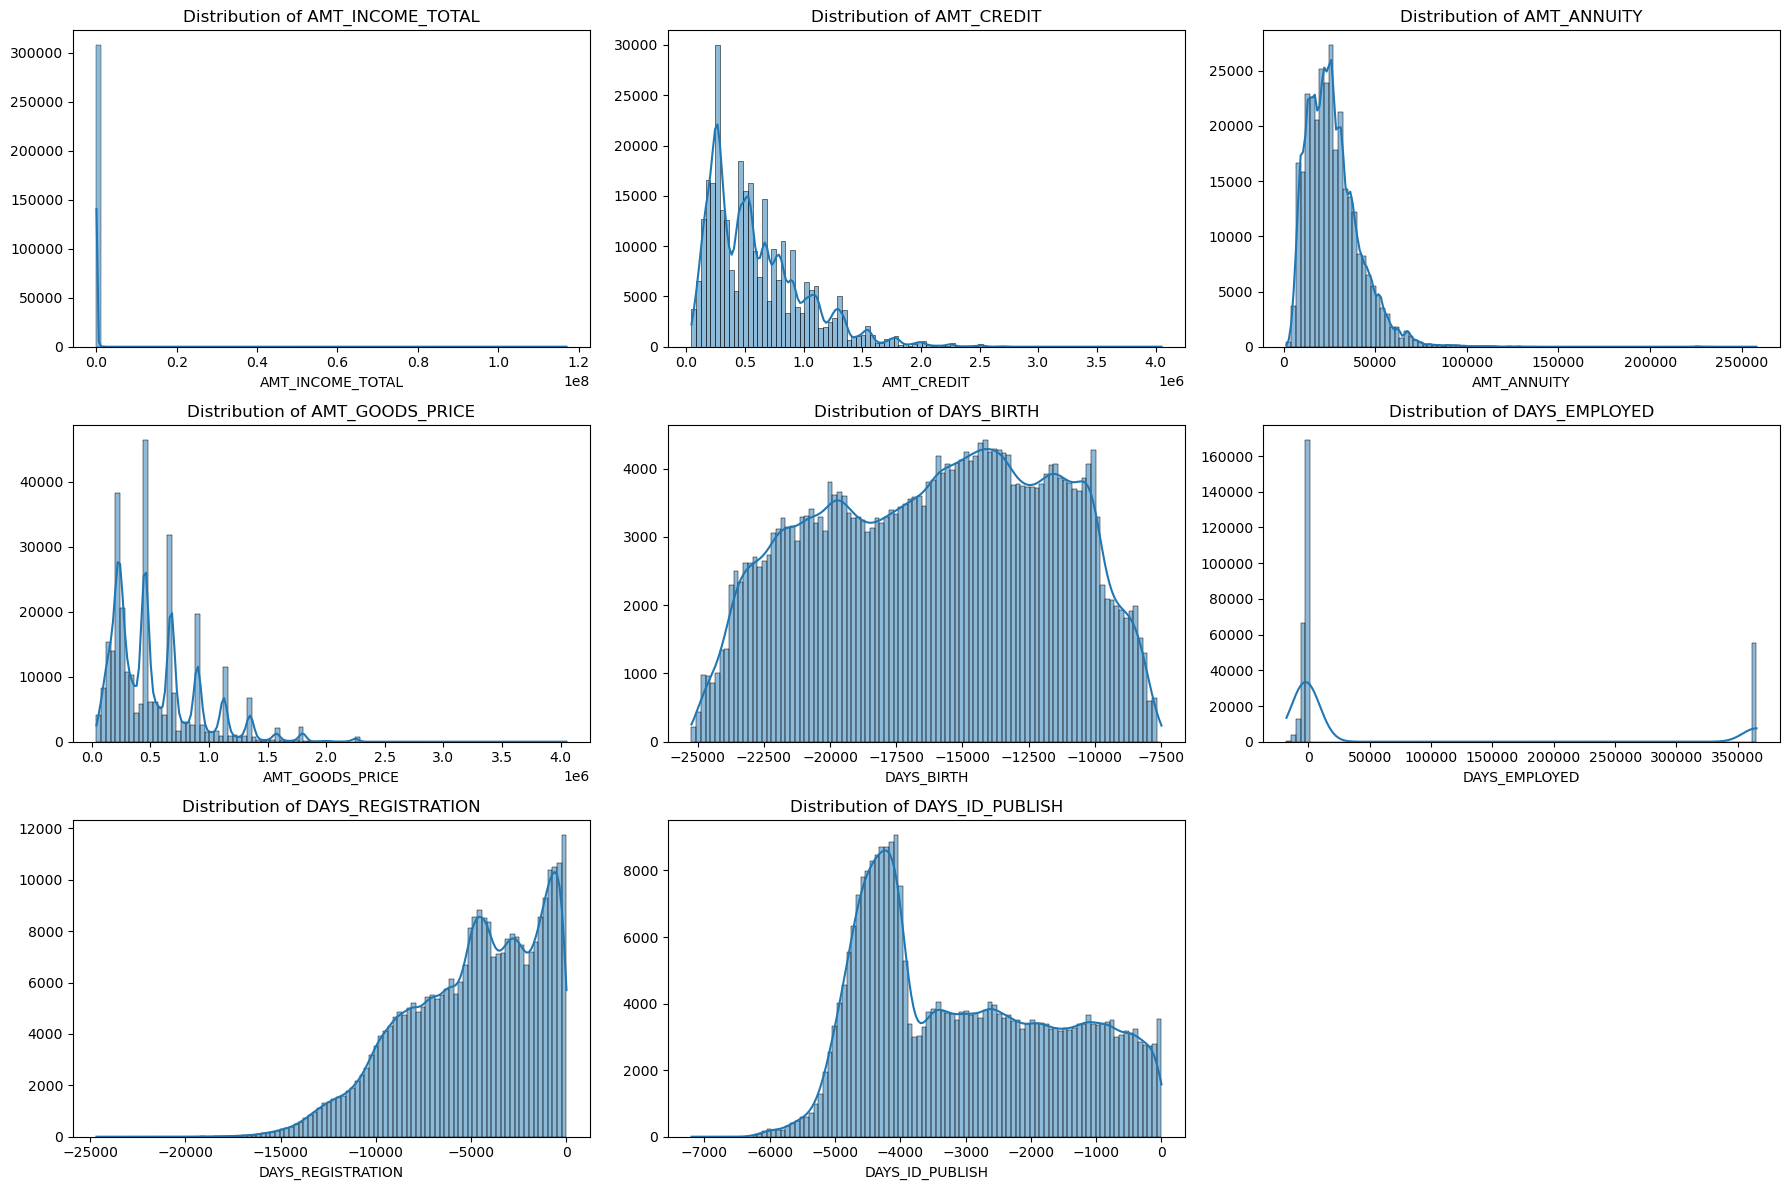

In [27]:
plot_distributions(cols)

In [28]:
application['DAYS_EMPLOYED'].describe()

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

In [29]:
application[application['DAYS_EMPLOYED'] != 365243]['DAYS_EMPLOYED'].describe()

count    252137.000000
mean      -2384.169325
std        2338.360162
min      -17912.000000
25%       -3175.000000
50%       -1648.000000
75%        -767.000000
max           0.000000
Name: DAYS_EMPLOYED, dtype: float64

The 'DAYS_EMPLOYED' column contains an issue, as the maximum value is 1000 years. I will replace all instances of 365243 with null.

In [30]:
application['DAYS_EMPLOYED'] = application['DAYS_EMPLOYED'].replace(365243, np.nan)

**Comparison of interval values with TARGET = 1 and TARGET = 0**

<Figure size 640x480 with 0 Axes>

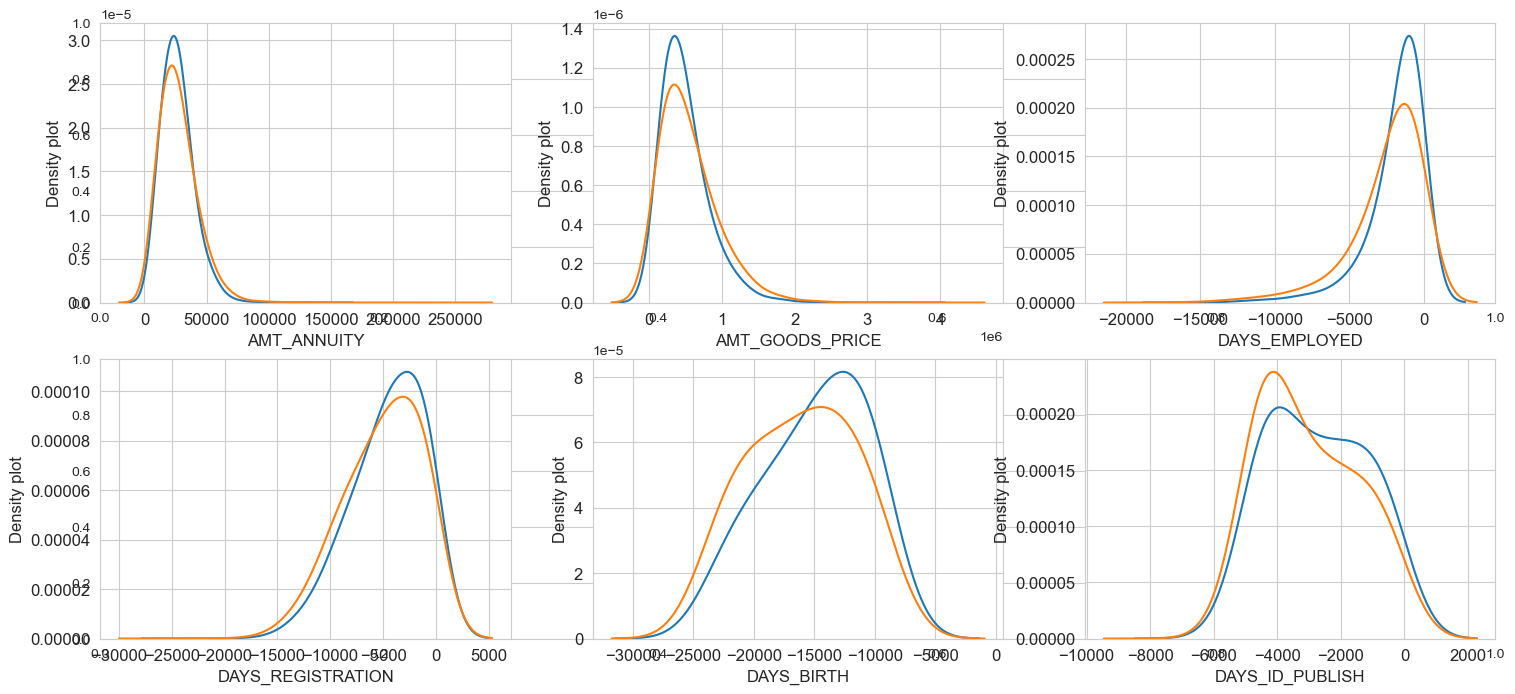

In [31]:
var = ['AMT_ANNUITY','AMT_GOODS_PRICE','DAYS_EMPLOYED', 'DAYS_REGISTRATION','DAYS_BIRTH','DAYS_ID_PUBLISH']
plot_distribution_comp(var,nrow=2)

### Bureau

Bureau data contains all client's previous credits provided by other financial institutions that were reported to Credit Bureau (for clients who have a loan in the sample). For every loan in the sample, there are as many rows as number of credits the client had in Credit Bureau before the application date. *SK_ID_CURR* is the key connecting application_train|test data with bureau data.

Let's merge application_train with bureau.

In [32]:
application_bureau = application.merge(bureau, left_on='SK_ID_CURR', right_on='SK_ID_CURR', how='inner')

In [33]:
def plot_b_stats(feature, label_rotation=False, horizontal_layout=True):
    # Value counts and sort descending
    temp = application_bureau[feature].value_counts()
    df1 = pd.DataFrame({feature: temp.index, 'Number of contracts': temp.values})

    # Calculate the percentage of target=1 per category value
    cat_perc = application_bureau[[feature, 'TARGET']].groupby([feature], as_index=False).mean()
    cat_perc.sort_values(by='TARGET', ascending=False, inplace=True)

    # Setup subplot
    if horizontal_layout:
        specs = [[{"type": "bar"}, {"type": "bar"}]]
        rows, cols = 1, 2
        subplot_titles = ('Number of Contracts', 'Percent of Target = 1')
        fig = make_subplots(rows=rows, cols=cols, specs=specs, subplot_titles=subplot_titles, horizontal_spacing=0.2)
    else:
        specs = [[{"type": "bar"}], [{"type": "bar"}]]
        rows, cols = 2, 1
        subplot_titles = ('Number of Contracts', 'Percent of Target = 1')
        fig = make_subplots(rows=rows, cols=cols, specs=specs, subplot_titles=subplot_titles, vertical_spacing=0.2)

    # First bar (Number of contracts) - sort descending
    fig.add_trace(
        go.Bar(
            y=df1.sort_values('Number of contracts', ascending=True)[feature],  # ascending=True vì y trên plotly sẽ đi từ dưới lên
            x=df1.sort_values('Number of contracts', ascending=True)['Number of contracts'],
            orientation='h',
        ),
        row=1, col=1
    )

    # Second bar (Percent target = 1) - sort descending
    fig.add_trace(
        go.Bar(
            y=cat_perc.sort_values('TARGET', ascending=True)[feature],  # ascending=True để bar dài nhất ở trên cùng
            x=cat_perc.sort_values('TARGET', ascending=True)['TARGET'] * 100,
            orientation='h',
        ),
        row=1 if horizontal_layout else 2, 
        col=2 if horizontal_layout else 1
    )

    # Update layout and axes
    fig.update_layout(
        height=600 if horizontal_layout else 900,
        width=1000,
        showlegend=False,
        title_text=f"Feature: {feature}",
        template="plotly_white"
    )

    fig.update_xaxes(title_text="Number of Contracts", row=1, col=1)
    fig.update_xaxes(title_text="Percent of Target = 1 (%)", row=1 if horizontal_layout else 2, col=2 if horizontal_layout else 1)

    fig.show()

In [34]:
plot_b_stats('CREDIT_ACTIVE')

Customers with a history of bad debt, as referenced by the credit bureau, are more likely to default. This factor is likely to have a significant impact in the model.

In [ ]:
plot_b_stats('CREDIT_CURRENCY')

In [ ]:
plot_b_stats('CREDIT_TYPE', True)

Certain types of loans in the past, particularly microloans and loans for the purchase of equipment, are strong indicators of the risk of default in current loans.

**Duration of credit (DAYS_CREDIT)**

In [ ]:
def plot_b_distributions(features):
    num_plots = len(features)
    num_cols = 3
    num_rows = (num_plots + num_cols - 1) // num_cols  # Tự động tính số hàng

    plt.figure(figsize=(num_cols * 6, num_rows * 4))

    for idx, feature in enumerate(features):
        plt.subplot(num_rows, num_cols, idx + 1)
        plt.title(f"Distribution of {feature}")
        sns.histplot(application_bureau[feature].dropna(), kde=True, bins=100)
        plt.ylabel('')
        plt.tight_layout()

    plt.show()

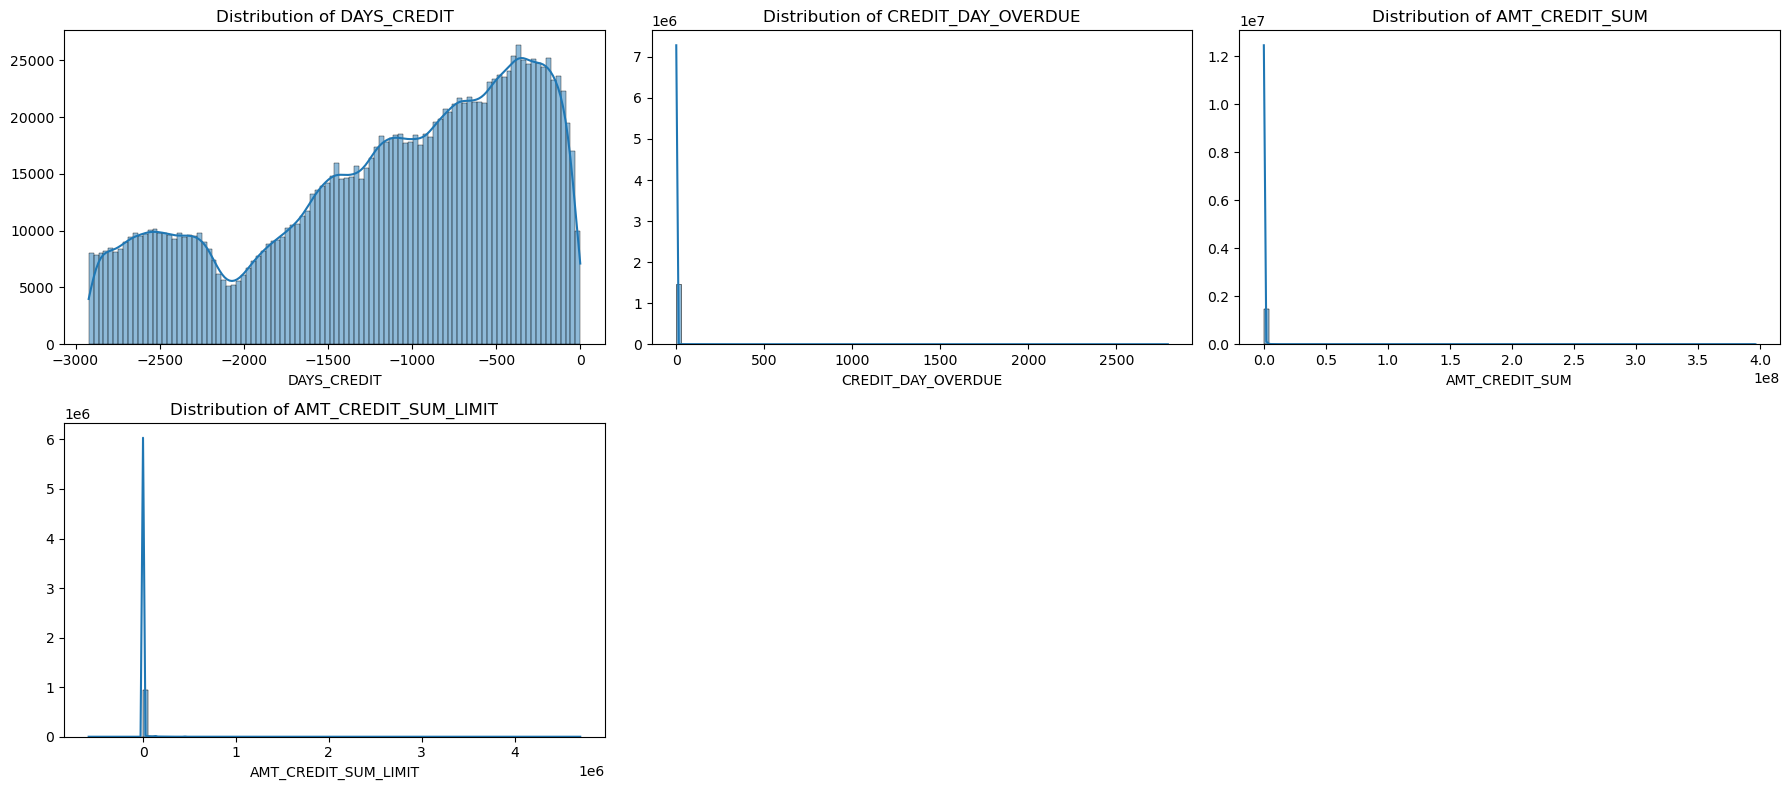

In [ ]:
credit_cols = ['DAYS_CREDIT', 'CREDIT_DAY_OVERDUE', 'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_LIMIT']
plot_b_distributions(credit_cols)

In [ ]:
# Plot distribution of multiple features, with TARGET = 1/0 on the same graph
def plot_b_distribution_comp(var,nrow=2):
    
    i = 0
    t1 = application_bureau.loc[application_bureau['TARGET'] != 0]
    t0 = application_bureau.loc[application_bureau['TARGET'] == 0]

    sns.set_style('whitegrid')
    plt.figure()
    fig, ax = plt.subplots(nrow,2,figsize=(15,6*nrow))

    for feature in var:
        i += 1
        plt.subplot(nrow,2,i)
        sns.kdeplot(t1[feature], bw=0.5,label="TARGET = 1")
        sns.kdeplot(t0[feature], bw=0.5,label="TARGET = 0")
        plt.ylabel('Density plot', fontsize=12)
        plt.xlabel(feature, fontsize=12)
        locs, labels = plt.xticks()
        plt.tick_params(axis='both', which='major', labelsize=12)
    plt.show()

<Figure size 640x480 with 0 Axes>

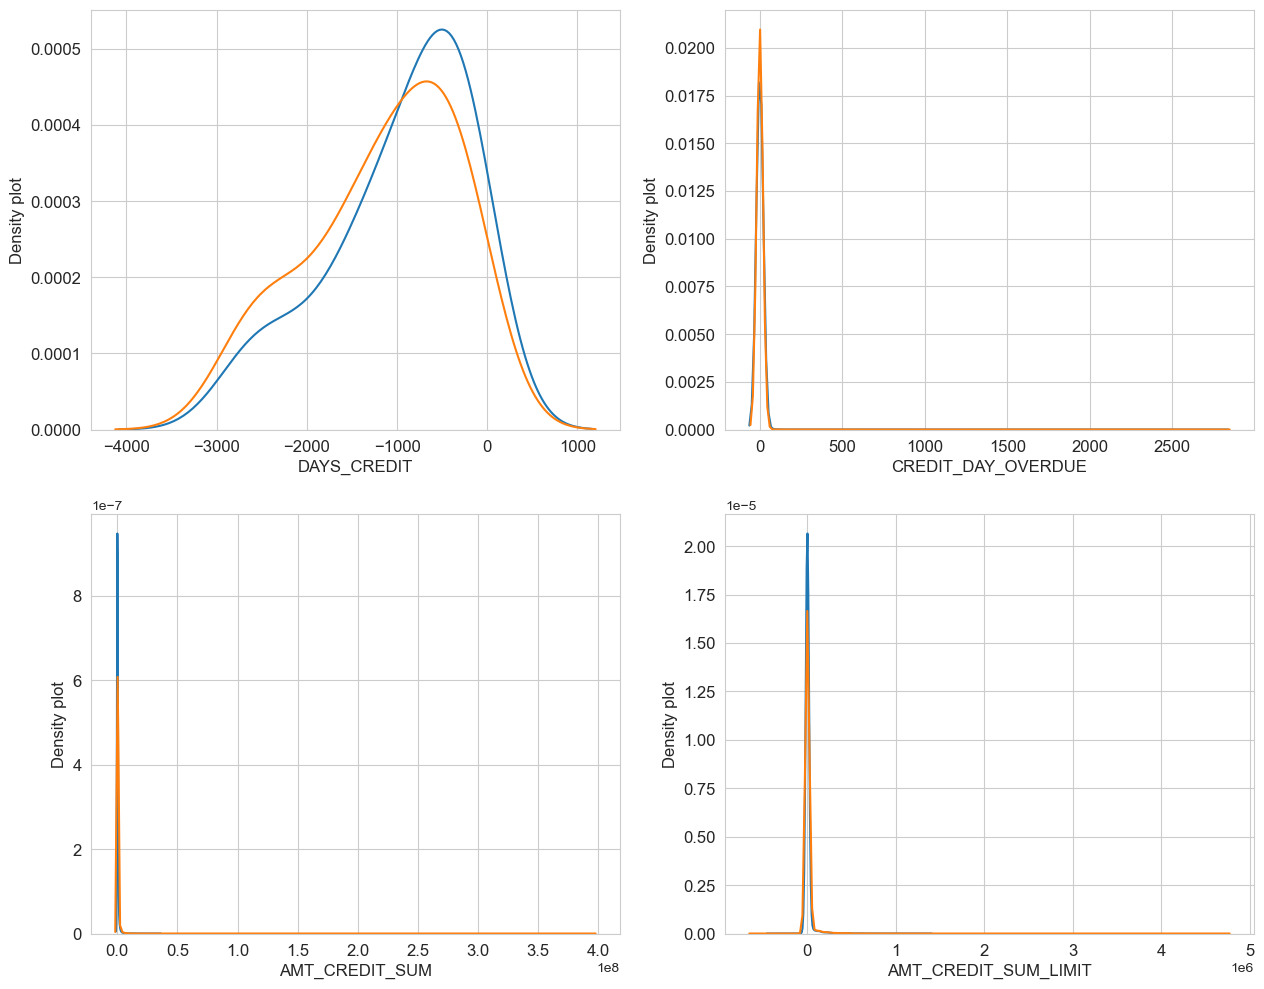

In [ ]:
var = ['DAYS_CREDIT','CREDIT_DAY_OVERDUE','AMT_CREDIT_SUM','AMT_CREDIT_SUM_LIMIT']

plot_b_distribution_comp(var, nrow=2)

### Previous application

In [35]:
application_prev = application.merge(prev_application, left_on='SK_ID_CURR', right_on='SK_ID_CURR', how='inner')

In [ ]:
print("The resulting dataframe `application_prev_train` has ",application_prev.shape[0]," rows and ", 
      application_prev.shape[1]," columns.")

The resulting dataframe `application_prev_train` has  1413701  rows and  158  columns.


In [ ]:
def plot_p_stats(feature,label_rotation=False,horizontal_layout=True):
    temp = application_prev[feature].value_counts()
    df1 = pd.DataFrame({feature: temp.index,'Number of contracts': temp.values})

    # Calculate the percentage of target=1 per category value
    cat_perc = application_prev[[feature, 'TARGET']].groupby([feature],as_index=False).mean()
    cat_perc.sort_values(by='TARGET', ascending=False, inplace=True)
    
    if(horizontal_layout):
        fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,6))
    else:
        fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(12,14))
    sns.set_color_codes("pastel")
    s = sns.barplot(ax=ax1, x = feature, y="Number of contracts",data=df1)
    if(label_rotation):
        s.set_xticklabels(s.get_xticklabels(),rotation=90)
    
    s = sns.barplot(ax=ax2, x = feature, y='TARGET', order=cat_perc[feature], data=cat_perc)
    if(label_rotation):
        s.set_xticklabels(s.get_xticklabels(),rotation=90)
    plt.ylabel('Percent of target with value 1 [%]', fontsize=10)
    plt.tick_params(axis='both', which='major', labelsize=10)

    plt.show()

In [ ]:
contract_col = ['NAME_CASH_LOAN_PURPOSE', 'NAME_CONTRACT_STATUS', 'NAME_PAYMENT_TYPE', 'NAME_CLIENT_TYPE']

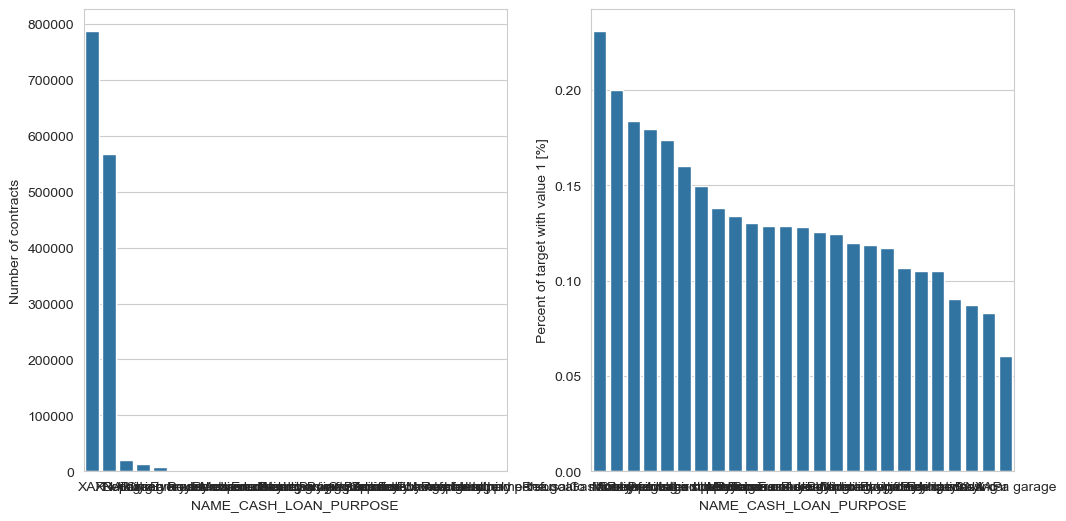

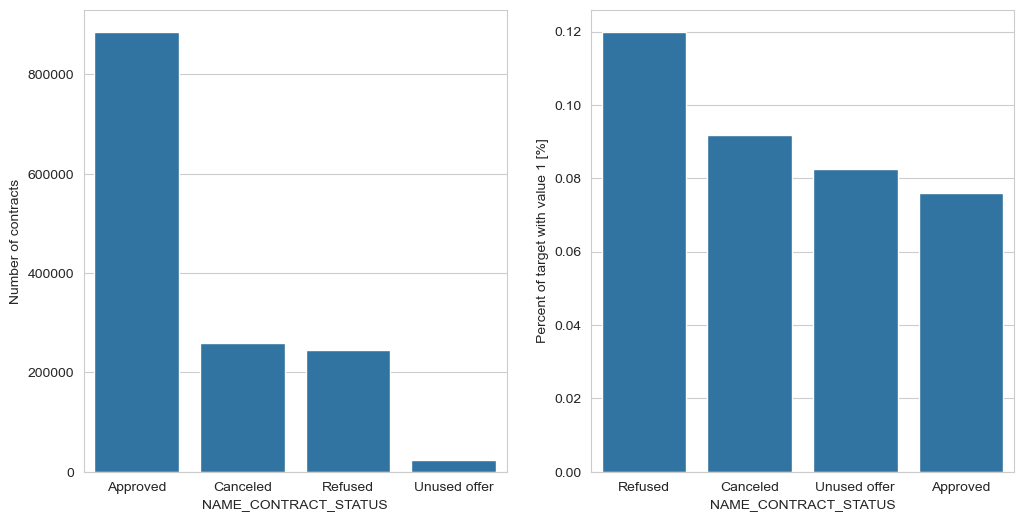

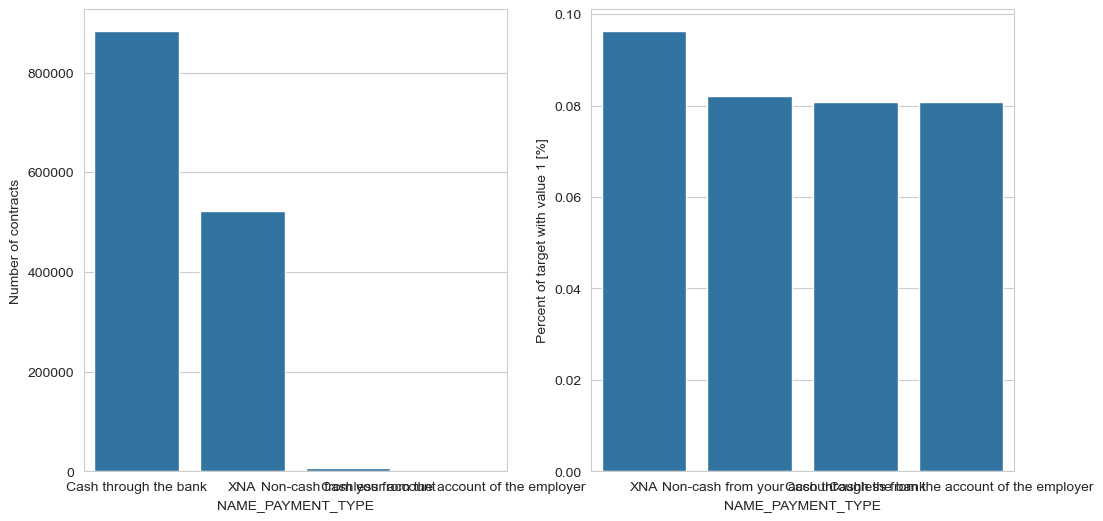

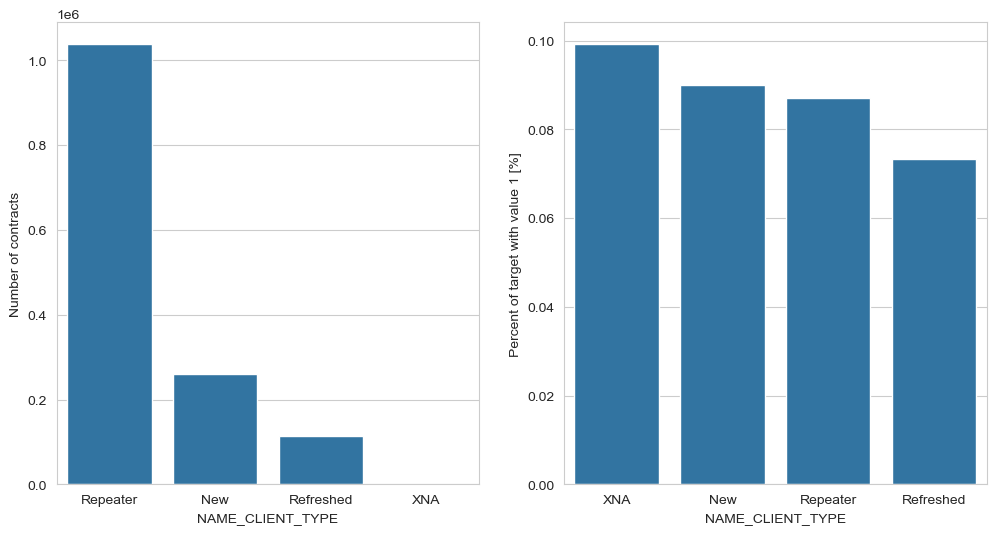

In [118]:
for i in contract_col: 
    plot_p_stats(i)

## Modelling

In [22]:
def outlier_detect(df, col):
    q1_col = Q1[col]
    iqr_col = IQR[col]
    q3_col = Q3[col]
    return df[((df[col] < (q1_col - 1.5 * iqr_col)) |(df[col] > (q3_col + 1.5 * iqr_col)))]

# ----------------------------------------------------------
def lower_outlier(df, col):
    q1_col = Q1[col]
    iqr_col = IQR[col]
    q3_col = Q3[col]
    lower = df[(df[col] < (q1_col - 1.5 * iqr_col))]
    return lower

# ----------------------------------------------------------
def upper_outlier(df, col):
    q1_col = Q1[col]
    iqr_col = IQR[col]
    q3_col = Q3[col]
    upper = df[(df[col] > (q3_col + 1.5 * iqr_col))]
    return upper

# ----------------------------------------------------------
def preprocess(df, col):
    print("-------------------- {} ---------------------\n".format(col))
    print("lower outlier: {}        upper outlier: {}\n".format(lower_outlier(df,col).shape[0], upper_outlier(df,col).shape[0]))
    plt.figure(figsize=(10,6))
    plt.subplot(2,1,1)
    df[col].plot(kind='box', subplots=True, sharex=False, vert=False)
    plt.subplot(2,1,2)
    df[col].plot(kind='density', subplots=True, sharex=False)
    plt.show()

# ----------------------------------------------------------
def preprocess_cat(df, col):
    print("-------------------- {} ---------------------\n".format(col))
    ax = df[col].value_counts(ascending = True).plot(kind='barh')
    ax.grid(False)  # Tắt grid
    plt.show()
    
# ----------------------------------------------------------
def replace_upper(df, col):
    q1_col = Q1[col]
    iqr_col = IQR[col]
    q3_col = Q3[col]
    upper = q3_col + 1.5 * iqr_col
    df[col] = df[col].clip(upper=upper)

def replace_lower(df, col):
    q1_col = Q1[col]
    iqr_col = IQR[col]
    q3_col = Q3[col]
    lower = q1_col - 1.5 * iqr_col
    df[col] = df[col].clip(lower=lower)

# ----------------------------------------------------------
def replace_mode(df, col):
    df[col] = df[col].fillna(df[col].mode()[0])
    print("NaN in {} replaced with {}".format(col, df[col].mode()[0]))

# ----------------------------------------------------------
def replace_mean(df, col):
    df[col] = df[col].fillna(df[col].mean())
    print("NaN in {} replaced with {}".format(col, round(df[col].mean(),2)))
    

def replace_median(df, col):
    df[col] = df[col].fillna(df[col].median())
    print("NaN in {} replaced with {}".format(col, df[col].median()))
    

# ----------------------------------------------------------
kfold = StratifiedKFold(n_splits=5, random_state=100, shuffle=True)

def cross_validation(x, y, model):
    result= cross_val_score(model, x, y, cv=kfold, scoring="roc_auc", n_jobs=-1)
    print("Score: %f" % result.mean())
    
# ----------------------------------------------------------
def RndSrch_Tune(model, X, y, params):
    
    clf = RandomizedSearchCV(model, params, scoring ='roc_auc', cv = kfold, n_jobs=-1, random_state=100)
    clf.fit(X, y)
    print("best score is :" , clf.best_score_)
    print("best estimator is :" , clf.best_estimator_)
    print("best Params is :" , clf.best_params_)
    return (clf.best_score_)

In [23]:
train = application.copy()
test = pd.read_csv(r"H:\ES\SHB\home-credit-default-risk\application_test.csv")

In [36]:
train.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=122)

In [37]:
train.shape

(307511, 122)

TARGET
0    282686
1     24825
Name: count, dtype: int64

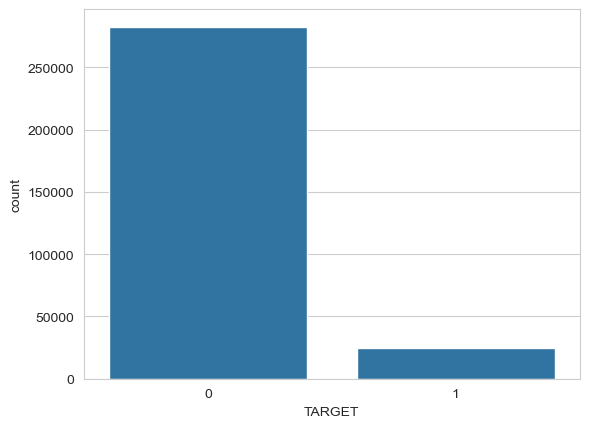

In [38]:
sns.countplot(x = "TARGET", data = train)
train.loc[:, 'TARGET'].value_counts()

In [39]:
print(train.info())
print("*******************************")
print(test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB
None
*******************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Columns: 121 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(40), object(16)
memory usage: 45.0+ MB
None


In [40]:
train.isnull().sum().sort_values(ascending = False)

COMMONAREA_MEDI             214865
COMMONAREA_AVG              214865
COMMONAREA_MODE             214865
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_AVG     213514
                             ...  
NAME_HOUSING_TYPE                0
NAME_FAMILY_STATUS               0
NAME_EDUCATION_TYPE              0
NAME_INCOME_TYPE                 0
SK_ID_CURR                       0
Length: 122, dtype: int64

In [41]:
pd.DataFrame(test.isnull().sum().sort_values(ascending = False))

,0
COMMONAREA_AVG,33495
COMMONAREA_MODE,33495
COMMONAREA_MEDI,33495
NONLIVINGAPARTMENTS_AVG,33347
NONLIVINGAPARTMENTS_MODE,33347
...,...
NAME_HOUSING_TYPE,0
NAME_FAMILY_STATUS,0
NAME_EDUCATION_TYPE,0
NAME_INCOME_TYPE,0


### Preprocessing 

#### Categorical

##### Null check

In [42]:
threshold_train = len(train) * 0.6
threshold_test = len(test) * 0.6
print(f"train: {int(threshold_train)}")
print(f'test: {int(threshold_test)}')

train: 184506
test: 29246


In [43]:
# check cột nào null quá threshold 
print("Train data:\n")
print(train.columns[train.isnull().sum() > int(threshold_train)])
print("----------------  ---------------------------")
print("Test data:\n")
print(test.columns[test.isnull().sum() > int(threshold_test)])

Train data:

Index(['OWN_CAR_AGE', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'FLOORSMIN_AVG',
       'LIVINGAPARTMENTS_AVG', 'NONLIVINGAPARTMENTS_AVG', 'YEARS_BUILD_MODE',
       'COMMONAREA_MODE', 'FLOORSMIN_MODE', 'LIVINGAPARTMENTS_MODE',
       'NONLIVINGAPARTMENTS_MODE', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI',
       'FLOORSMIN_MEDI', 'LIVINGAPARTMENTS_MEDI', 'NONLIVINGAPARTMENTS_MEDI',
       'FONDKAPREMONT_MODE'],
      dtype='object')
----------------  ---------------------------
Test data:

Index(['OWN_CAR_AGE', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'FLOORSMIN_AVG',
       'LIVINGAPARTMENTS_AVG', 'NONLIVINGAPARTMENTS_AVG', 'YEARS_BUILD_MODE',
       'COMMONAREA_MODE', 'FLOORSMIN_MODE', 'LIVINGAPARTMENTS_MODE',
       'NONLIVINGAPARTMENTS_MODE', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI',
       'FLOORSMIN_MEDI', 'LIVINGAPARTMENTS_MEDI', 'NONLIVINGAPARTMENTS_MEDI',
       'FONDKAPREMONT_MODE'],
      dtype='object')


In [44]:
train_new = train.dropna(axis=1, thresh=threshold_train)
print("New data shape:")
print(f'Train: {train_new.shape}')
test_new = test.dropna(axis=1, thresh=threshold_test)
print(f'Test: {test_new.shape}')

New data shape:
Train: (307511, 73)
Test: (48744, 72)


In [45]:
#categorical_feature = train_new.dtypes==object
#categorical_feature_list = train_new.columns[categorical_feature].tolist()
categorical_feature_list = [
'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE',
'WEEKDAY_APPR_PROCESS_START',
'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 
'FLAG_PHONE', 'FLAG_EMAIL', 'REG_REGION_NOT_LIVE_REGION', 
'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION',
'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY'
] + [f"FLAG_DOCUMENT_{i}" for i in range(2, 22)]
categorical = train_new[categorical_feature_list]

#categorical_feature_test = test_new.dtypes==object
#categorical_feature_test_list = test_new.columns[categorical_feature_test].tolist()
categorical_test = test_new[categorical_feature_list]

categorical.head()

,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,...,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21
0,Cash loans,M,N,Y,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,Laborers,...,0,0,0,0,0,0,0,0,0,0
1,Cash loans,F,N,N,Family,State servant,Higher education,Married,House / apartment,Core staff,...,0,0,0,0,0,0,0,0,0,0
2,Revolving loans,M,Y,Y,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,Laborers,...,0,0,0,0,0,0,0,0,0,0
3,Cash loans,F,N,Y,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,Laborers,...,0,0,0,0,0,0,0,0,0,0
4,Cash loans,M,N,Y,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,Core staff,...,0,0,0,0,0,0,0,0,0,0


In [46]:
categorical.isnull().sum().sort_values(ascending = False)

OCCUPATION_TYPE                96391
NAME_TYPE_SUITE                 1292
NAME_CONTRACT_TYPE                 0
FLAG_DOCUMENT_11                   0
FLAG_DOCUMENT_3                    0
FLAG_DOCUMENT_4                    0
FLAG_DOCUMENT_5                    0
FLAG_DOCUMENT_6                    0
FLAG_DOCUMENT_7                    0
FLAG_DOCUMENT_8                    0
FLAG_DOCUMENT_9                    0
FLAG_DOCUMENT_10                   0
FLAG_DOCUMENT_13                   0
FLAG_DOCUMENT_12                   0
LIVE_CITY_NOT_WORK_CITY            0
FLAG_DOCUMENT_14                   0
FLAG_DOCUMENT_15                   0
FLAG_DOCUMENT_16                   0
FLAG_DOCUMENT_17                   0
FLAG_DOCUMENT_18                   0
FLAG_DOCUMENT_19                   0
FLAG_DOCUMENT_20                   0
FLAG_DOCUMENT_2                    0
REG_CITY_NOT_WORK_CITY             0
CODE_GENDER                        0
REG_CITY_NOT_LIVE_CITY             0
FLAG_OWN_CAR                       0
F

In [47]:
categorical_test.isnull().sum().sort_values(ascending = False)

OCCUPATION_TYPE                15605
NAME_TYPE_SUITE                  911
NAME_CONTRACT_TYPE                 0
FLAG_DOCUMENT_11                   0
FLAG_DOCUMENT_3                    0
FLAG_DOCUMENT_4                    0
FLAG_DOCUMENT_5                    0
FLAG_DOCUMENT_6                    0
FLAG_DOCUMENT_7                    0
FLAG_DOCUMENT_8                    0
FLAG_DOCUMENT_9                    0
FLAG_DOCUMENT_10                   0
FLAG_DOCUMENT_13                   0
FLAG_DOCUMENT_12                   0
LIVE_CITY_NOT_WORK_CITY            0
FLAG_DOCUMENT_14                   0
FLAG_DOCUMENT_15                   0
FLAG_DOCUMENT_16                   0
FLAG_DOCUMENT_17                   0
FLAG_DOCUMENT_18                   0
FLAG_DOCUMENT_19                   0
FLAG_DOCUMENT_20                   0
FLAG_DOCUMENT_2                    0
REG_CITY_NOT_WORK_CITY             0
CODE_GENDER                        0
REG_CITY_NOT_LIVE_CITY             0
FLAG_OWN_CAR                       0
F

In [48]:
col_names_cat = categorical.columns

-------------------- NAME_CONTRACT_TYPE ---------------------



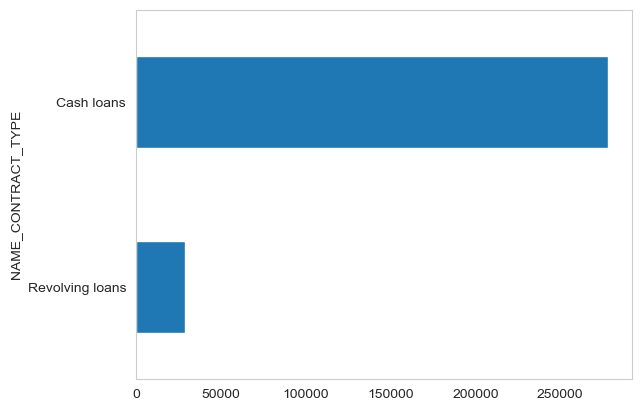

-------------------- CODE_GENDER ---------------------



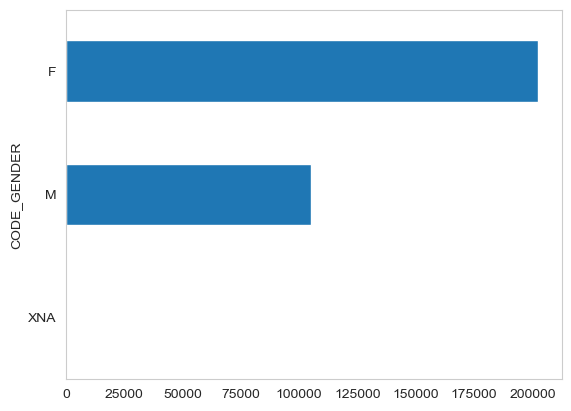

-------------------- FLAG_OWN_CAR ---------------------



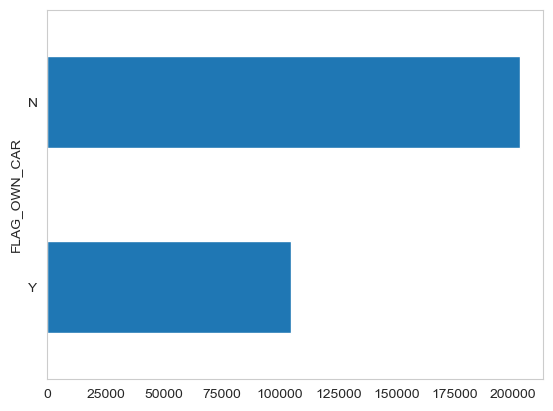

-------------------- FLAG_OWN_REALTY ---------------------



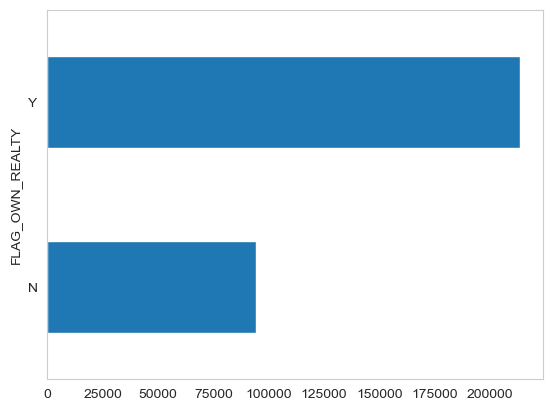

-------------------- NAME_TYPE_SUITE ---------------------



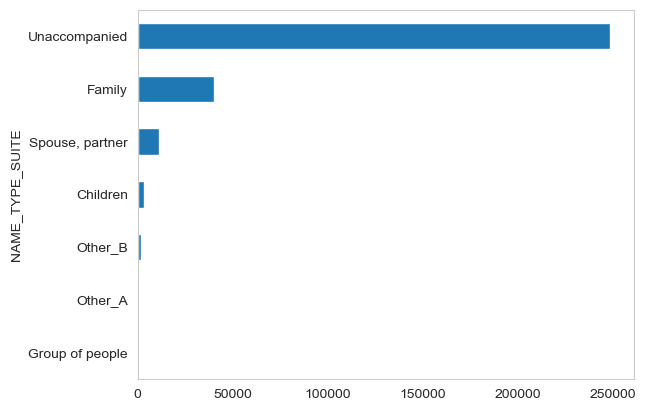

-------------------- NAME_INCOME_TYPE ---------------------



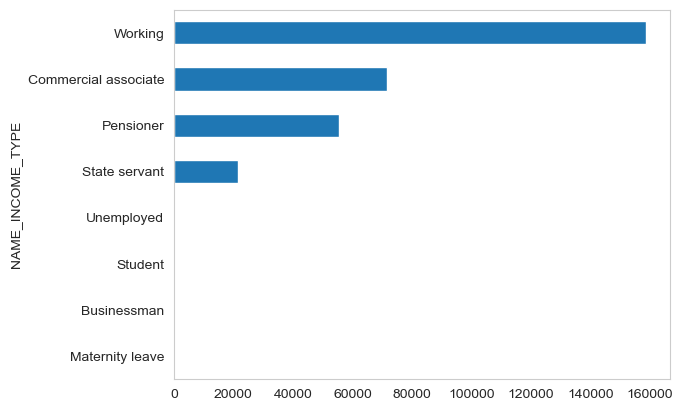

-------------------- NAME_EDUCATION_TYPE ---------------------



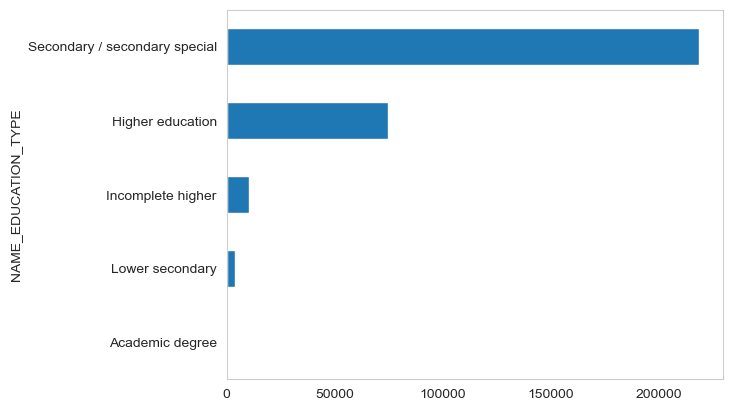

-------------------- NAME_FAMILY_STATUS ---------------------



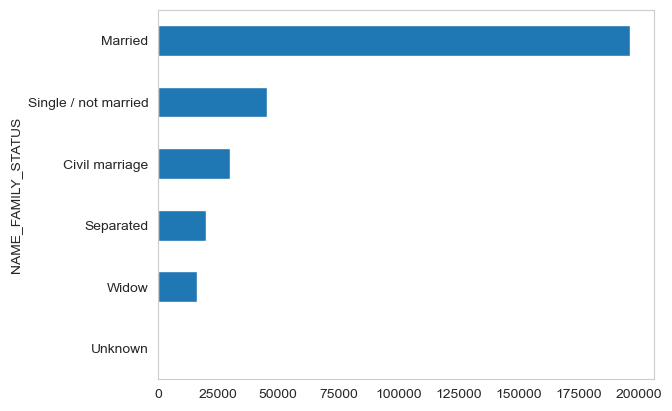

-------------------- NAME_HOUSING_TYPE ---------------------



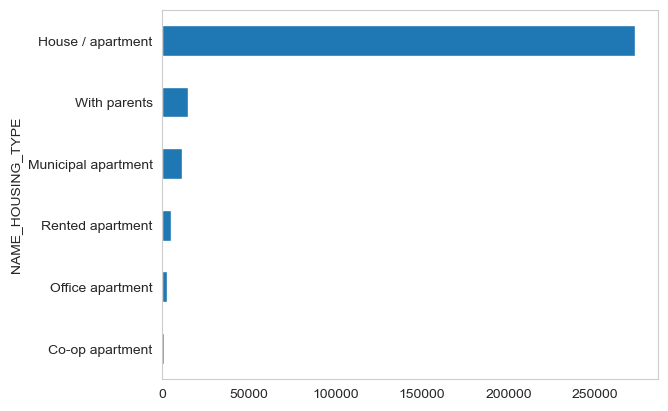

-------------------- OCCUPATION_TYPE ---------------------



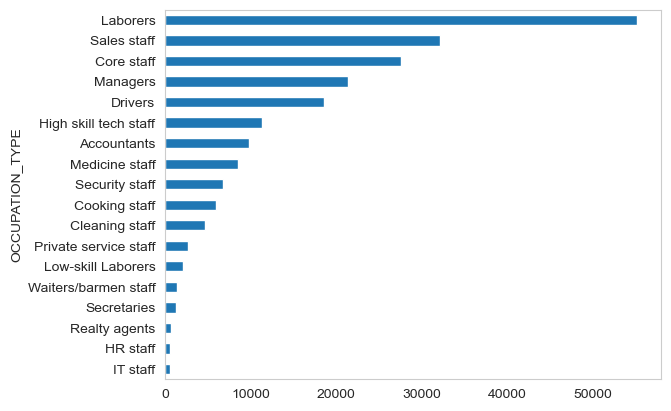

-------------------- ORGANIZATION_TYPE ---------------------



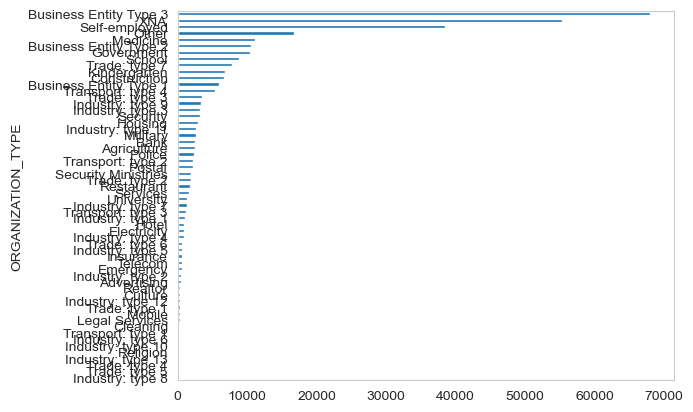

-------------------- WEEKDAY_APPR_PROCESS_START ---------------------



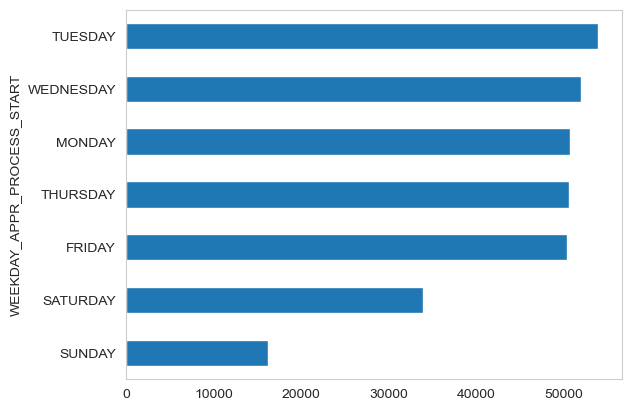

-------------------- FLAG_MOBIL ---------------------



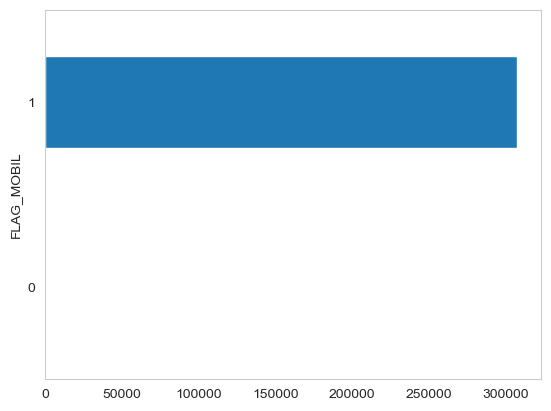

-------------------- FLAG_EMP_PHONE ---------------------



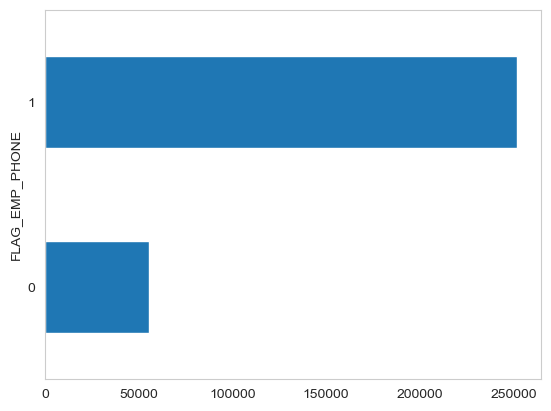

-------------------- FLAG_WORK_PHONE ---------------------



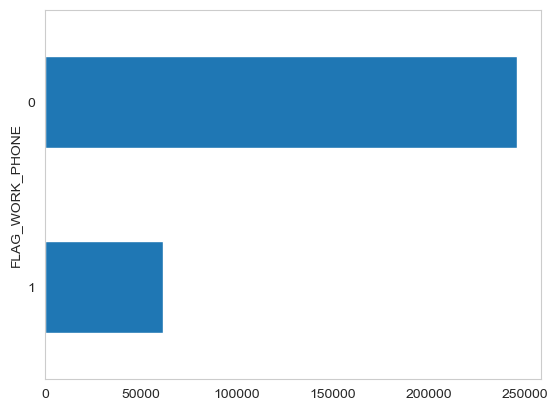

-------------------- FLAG_CONT_MOBILE ---------------------



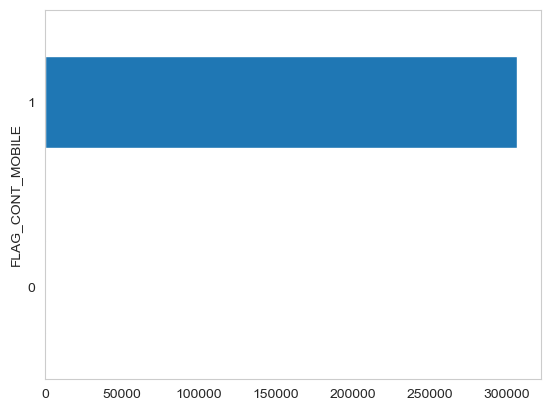

-------------------- FLAG_PHONE ---------------------



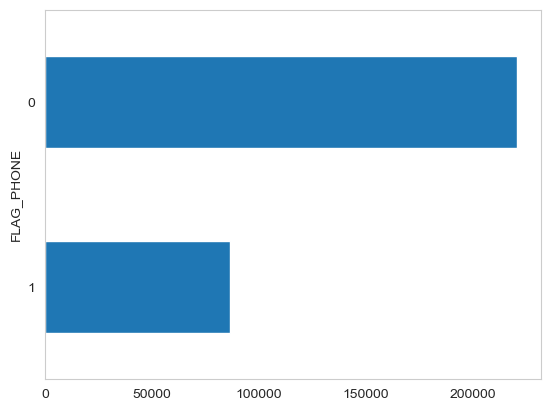

-------------------- FLAG_EMAIL ---------------------



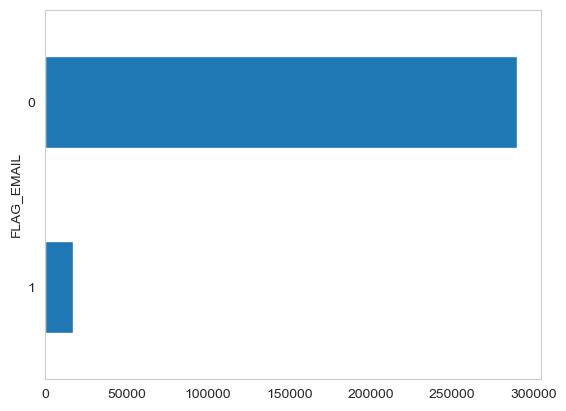

-------------------- REG_REGION_NOT_LIVE_REGION ---------------------



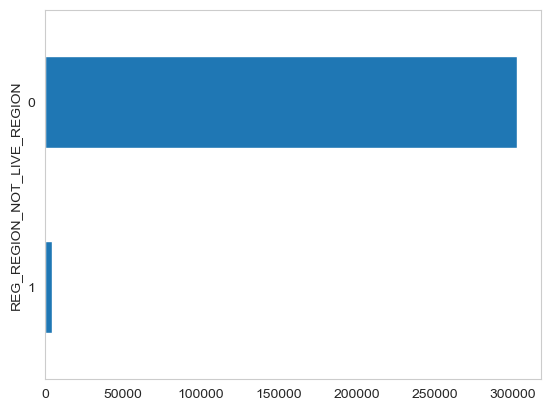

-------------------- REG_REGION_NOT_WORK_REGION ---------------------



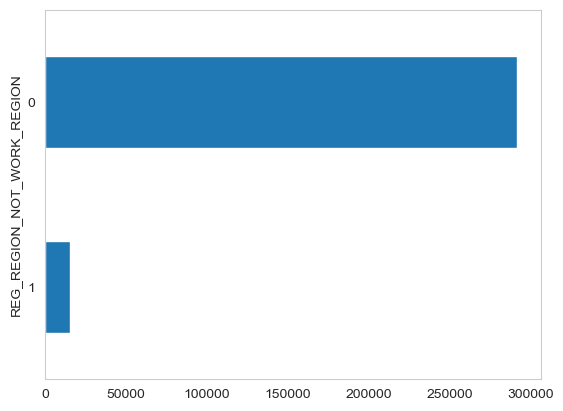

-------------------- LIVE_REGION_NOT_WORK_REGION ---------------------



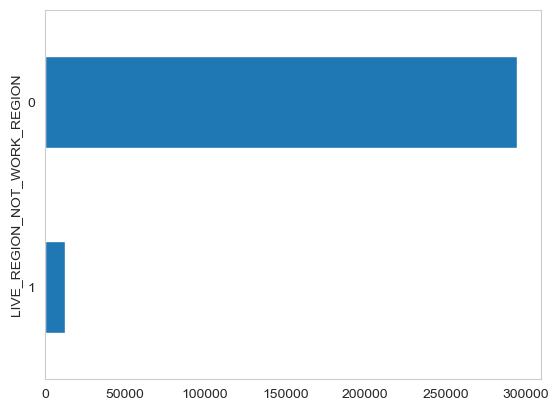

-------------------- REG_CITY_NOT_LIVE_CITY ---------------------



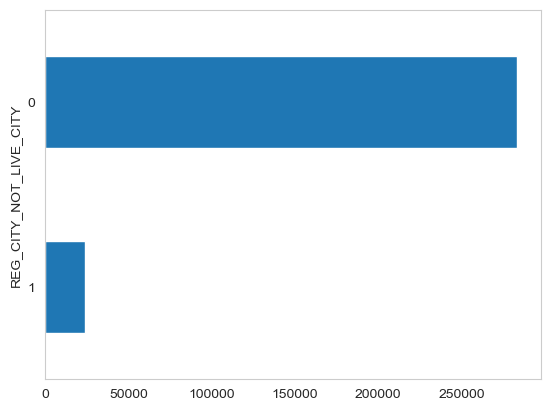

-------------------- REG_CITY_NOT_WORK_CITY ---------------------



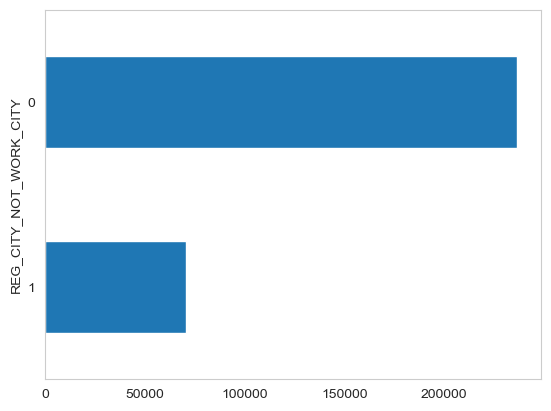

-------------------- LIVE_CITY_NOT_WORK_CITY ---------------------



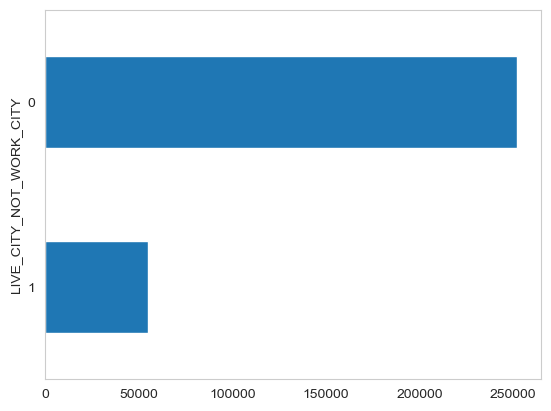

-------------------- FLAG_DOCUMENT_2 ---------------------



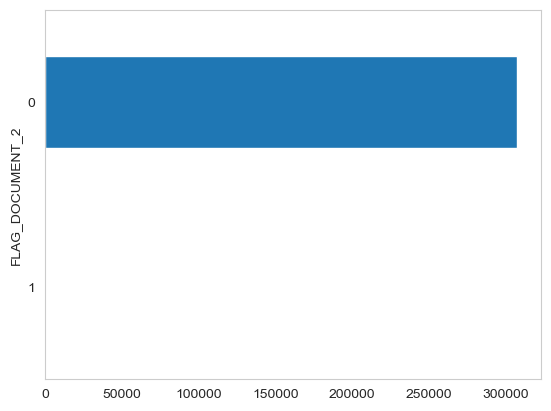

-------------------- FLAG_DOCUMENT_3 ---------------------



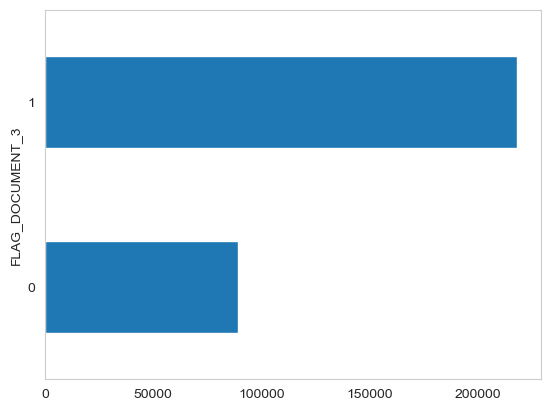

-------------------- FLAG_DOCUMENT_4 ---------------------



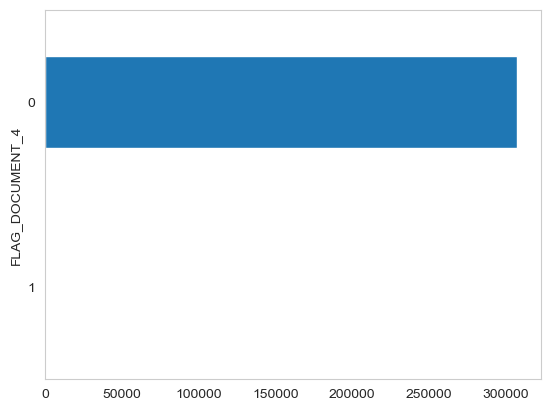

-------------------- FLAG_DOCUMENT_5 ---------------------



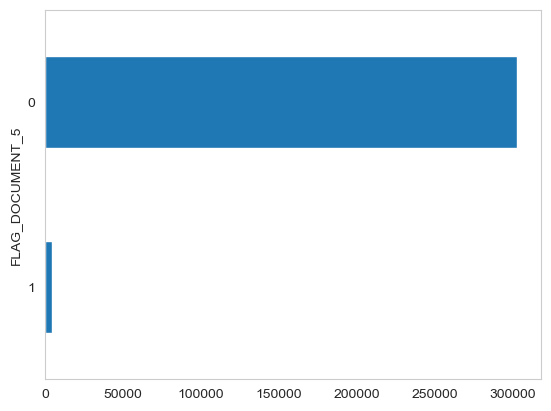

-------------------- FLAG_DOCUMENT_6 ---------------------



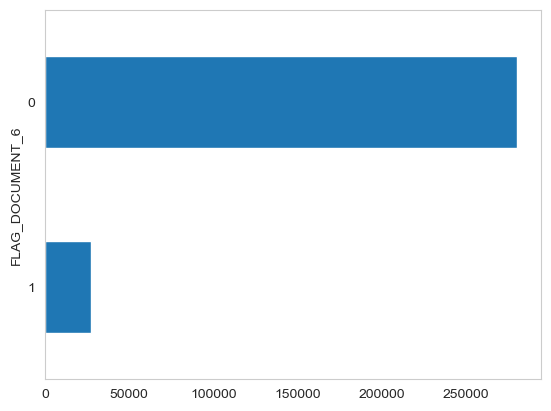

-------------------- FLAG_DOCUMENT_7 ---------------------



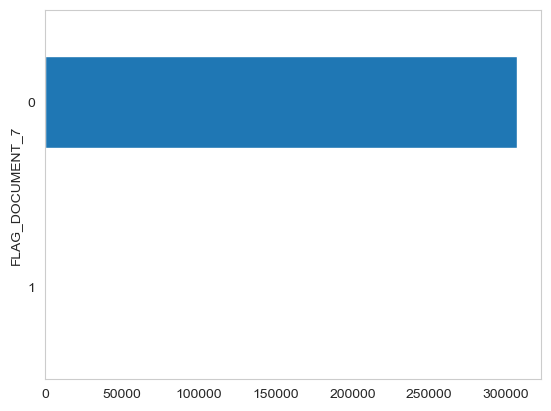

-------------------- FLAG_DOCUMENT_8 ---------------------



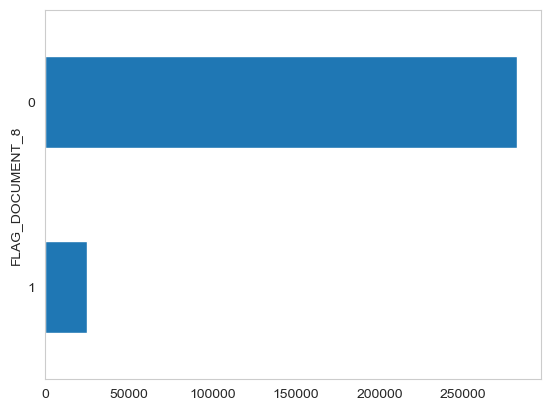

-------------------- FLAG_DOCUMENT_9 ---------------------



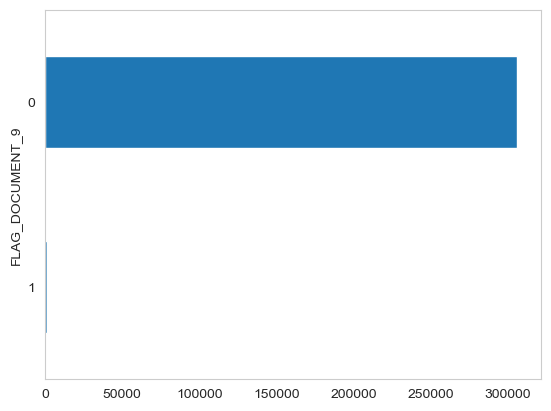

-------------------- FLAG_DOCUMENT_10 ---------------------



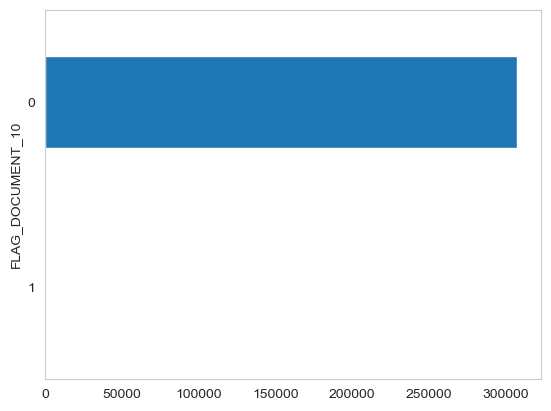

-------------------- FLAG_DOCUMENT_11 ---------------------



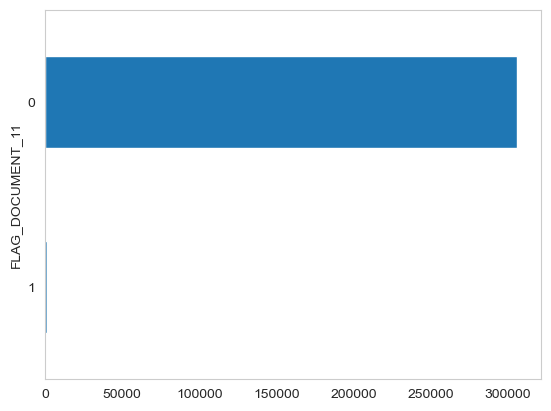

-------------------- FLAG_DOCUMENT_12 ---------------------



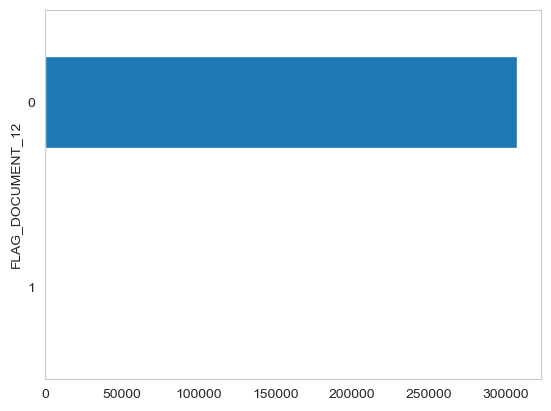

-------------------- FLAG_DOCUMENT_13 ---------------------



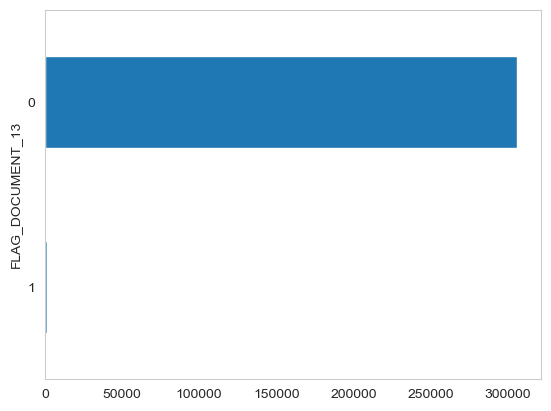

-------------------- FLAG_DOCUMENT_14 ---------------------



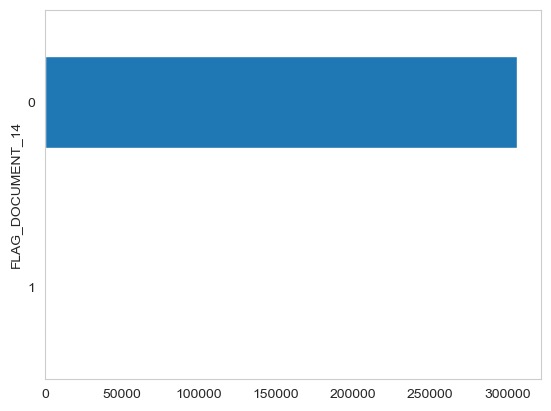

-------------------- FLAG_DOCUMENT_15 ---------------------



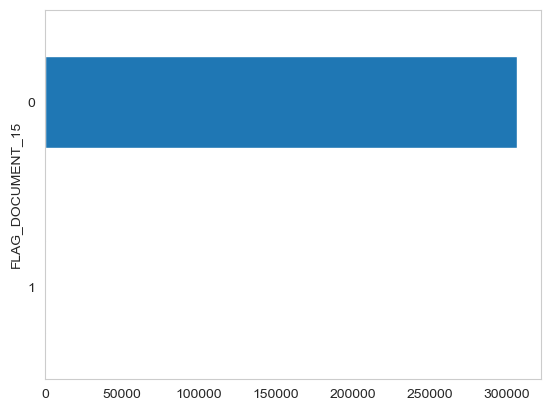

-------------------- FLAG_DOCUMENT_16 ---------------------



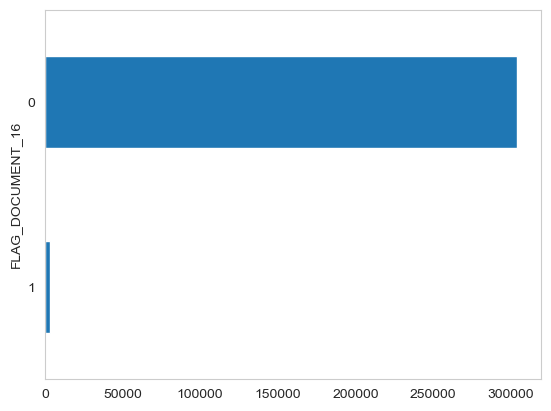

-------------------- FLAG_DOCUMENT_17 ---------------------



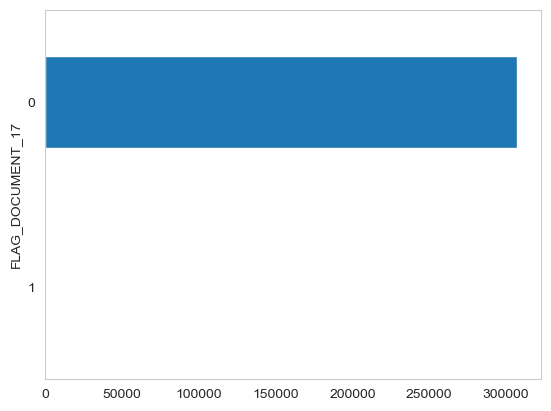

-------------------- FLAG_DOCUMENT_18 ---------------------



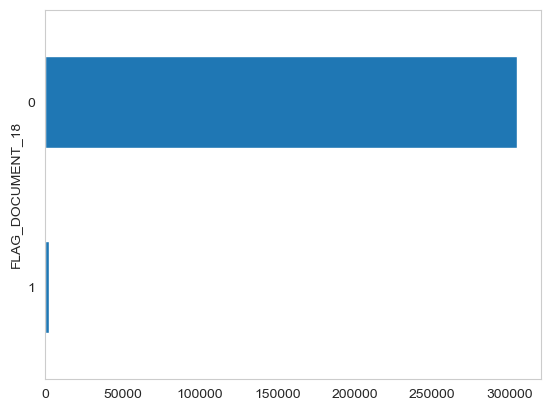

-------------------- FLAG_DOCUMENT_19 ---------------------



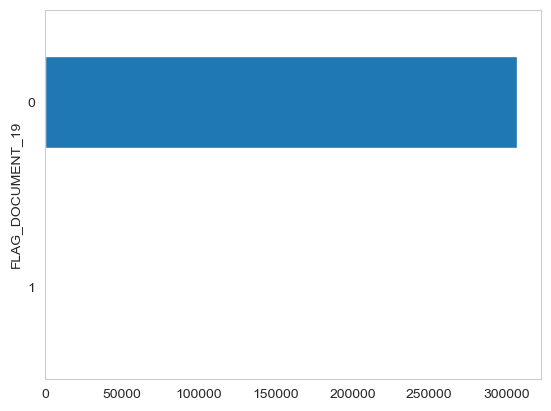

-------------------- FLAG_DOCUMENT_20 ---------------------



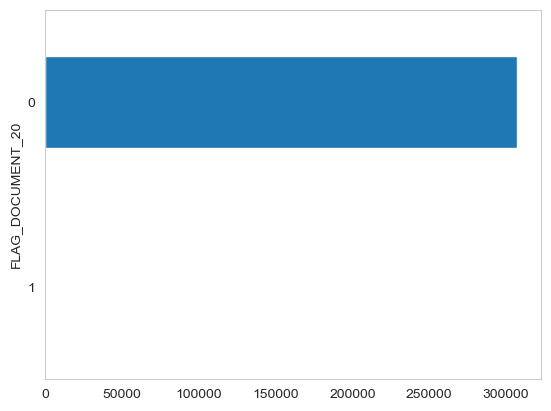

-------------------- FLAG_DOCUMENT_21 ---------------------



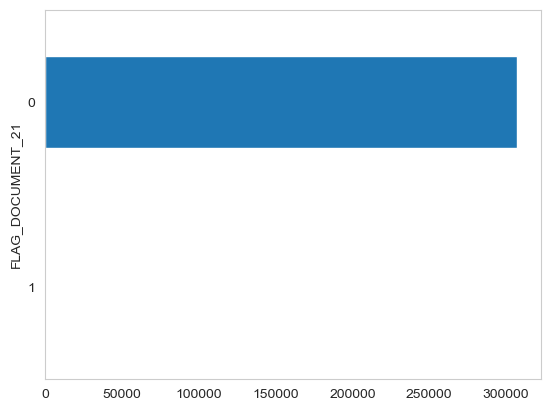

In [49]:
for i in range(len(col_names_cat)):
    preprocess_cat(categorical, col_names_cat[i])

In [50]:
print("Train:\n")
for i in range(len(col_names_cat)):
    replace_mode(categorical, col_names_cat[i])

print("----------------------------------------")
print("Test:\n")
for i in range(len(col_names_cat)):
    replace_mode(categorical_test, col_names_cat[i])

Train:

NaN in NAME_CONTRACT_TYPE replaced with Cash loans
NaN in CODE_GENDER replaced with F
NaN in FLAG_OWN_CAR replaced with N
NaN in FLAG_OWN_REALTY replaced with Y
NaN in NAME_TYPE_SUITE replaced with Unaccompanied
NaN in NAME_INCOME_TYPE replaced with Working
NaN in NAME_EDUCATION_TYPE replaced with Secondary / secondary special
NaN in NAME_FAMILY_STATUS replaced with Married
NaN in NAME_HOUSING_TYPE replaced with House / apartment
NaN in OCCUPATION_TYPE replaced with Laborers
NaN in ORGANIZATION_TYPE replaced with Business Entity Type 3
NaN in WEEKDAY_APPR_PROCESS_START replaced with TUESDAY
NaN in FLAG_MOBIL replaced with 1
NaN in FLAG_EMP_PHONE replaced with 1
NaN in FLAG_WORK_PHONE replaced with 0
NaN in FLAG_CONT_MOBILE replaced with 1
NaN in FLAG_PHONE replaced with 0
NaN in FLAG_EMAIL replaced with 0
NaN in REG_REGION_NOT_LIVE_REGION replaced with 0
NaN in REG_REGION_NOT_WORK_REGION replaced with 0
NaN in LIVE_REGION_NOT_WORK_REGION replaced with 0
NaN in REG_CITY_NOT_LIVE

In [51]:
categorical.isnull().sum().sort_values(ascending = False)

NAME_CONTRACT_TYPE             0
CODE_GENDER                    0
FLAG_DOCUMENT_2                0
FLAG_DOCUMENT_3                0
FLAG_DOCUMENT_4                0
FLAG_DOCUMENT_5                0
FLAG_DOCUMENT_6                0
FLAG_DOCUMENT_7                0
FLAG_DOCUMENT_8                0
FLAG_DOCUMENT_9                0
FLAG_DOCUMENT_10               0
FLAG_DOCUMENT_11               0
FLAG_DOCUMENT_12               0
FLAG_DOCUMENT_13               0
FLAG_DOCUMENT_14               0
FLAG_DOCUMENT_15               0
FLAG_DOCUMENT_16               0
FLAG_DOCUMENT_17               0
FLAG_DOCUMENT_18               0
FLAG_DOCUMENT_19               0
FLAG_DOCUMENT_20               0
LIVE_CITY_NOT_WORK_CITY        0
REG_CITY_NOT_WORK_CITY         0
REG_CITY_NOT_LIVE_CITY         0
ORGANIZATION_TYPE              0
FLAG_OWN_CAR                   0
FLAG_OWN_REALTY                0
NAME_TYPE_SUITE                0
NAME_INCOME_TYPE               0
NAME_EDUCATION_TYPE            0
NAME_FAMIL

In [52]:
categorical_test.isnull().sum().sort_values(ascending = False)

NAME_CONTRACT_TYPE             0
CODE_GENDER                    0
FLAG_DOCUMENT_2                0
FLAG_DOCUMENT_3                0
FLAG_DOCUMENT_4                0
FLAG_DOCUMENT_5                0
FLAG_DOCUMENT_6                0
FLAG_DOCUMENT_7                0
FLAG_DOCUMENT_8                0
FLAG_DOCUMENT_9                0
FLAG_DOCUMENT_10               0
FLAG_DOCUMENT_11               0
FLAG_DOCUMENT_12               0
FLAG_DOCUMENT_13               0
FLAG_DOCUMENT_14               0
FLAG_DOCUMENT_15               0
FLAG_DOCUMENT_16               0
FLAG_DOCUMENT_17               0
FLAG_DOCUMENT_18               0
FLAG_DOCUMENT_19               0
FLAG_DOCUMENT_20               0
LIVE_CITY_NOT_WORK_CITY        0
REG_CITY_NOT_WORK_CITY         0
REG_CITY_NOT_LIVE_CITY         0
ORGANIZATION_TYPE              0
FLAG_OWN_CAR                   0
FLAG_OWN_REALTY                0
NAME_TYPE_SUITE                0
NAME_INCOME_TYPE               0
NAME_EDUCATION_TYPE            0
NAME_FAMIL

In [53]:
#categorical.drop(['ORGANIZATION_TYPE'], axis=1, inplace=True)
#categorical_test.drop(['ORGANIZATION_TYPE'], axis=1, inplace=True)

In [54]:
le = LabelEncoder() 
categorical = categorical.apply(lambda col_names_cat: le.fit_transform(col_names_cat)) 
categorical_test = categorical_test.apply(lambda col_names_cat: le.fit_transform(col_names_cat)) 
categorical.head()

,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,...,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21
0,0,1,0,1,6,7,4,3,1,8,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,1,4,1,1,1,3,...,0,0,0,0,0,0,0,0,0,0
2,1,1,1,1,6,7,4,3,1,8,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,1,6,7,4,0,1,8,...,0,0,0,0,0,0,0,0,0,0
4,0,1,0,1,6,7,4,3,1,3,...,0,0,0,0,0,0,0,0,0,0


In [92]:
print("Train: ",categorical.shape)
print("Test: ",categorical_test.shape)

Train:  (307511, 43)
Test:  (48744, 43)


#### Numerical

In [55]:
#numeric_feature = train_new.dtypes!=object
#numeric_feature_list = train_new.columns[numeric_feature].tolist()  
numeric_feature_list = [col for col in train_new.columns if col not in categorical_feature_list]

numeric = train_new[numeric_feature_list]

#numeric_feature_test = test_new.dtypes!=object
#numeric_feature_test_list = test_new.columns[numeric_feature_test].tolist() 
numeric_feature_test_list = [col for col in test_new.columns if col not in categorical_feature_list and col != 'TARGET']
numeric_test = test_new[numeric_feature_test_list]

numeric.head()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,0,202500.0,406597.5,24700.5,351000.0,0.018801,-9461,-637,...,2.0,2.0,2.0,-1134.0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,0,270000.0,1293502.5,35698.5,1129500.0,0.003541,-16765,-1188,...,0.0,1.0,0.0,-828.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,0,67500.0,135000.0,6750.0,135000.0,0.010032,-19046,-225,...,0.0,0.0,0.0,-815.0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,0,135000.0,312682.5,29686.5,297000.0,0.008019,-19005,-3039,...,0.0,2.0,0.0,-617.0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,0,121500.0,513000.0,21865.5,513000.0,0.028663,-19932,-3038,...,0.0,0.0,0.0,-1106.0,0.0,0.0,0.0,0.0,0.0,0.0


In [56]:
numeric.columns

Index(['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
       'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
       'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'CNT_FAM_MEMBERS',
       'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY',
       'HOUR_APPR_PROCESS_START', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
       'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE',
       'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE',
       'DAYS_LAST_PHONE_CHANGE', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object')

In [ ]:
#discrete_features = numeric.dtypes == np.int64
#discrete_feature_list = numeric.columns[discrete_features].tolist()
discrete_feature_list = [
    "CNT_CHILDREN",              
    "CNT_FAM_MEMBERS",           
    "DAYS_BIRTH",                
    "DAYS_EMPLOYED",           
    "DAYS_ID_PUBLISH",          
    "DAYS_REGISTRATION",         
    "DAYS_LAST_PHONE_CHANGE",    
    "REGION_RATING_CLIENT",     
    "REGION_RATING_CLIENT_W_CITY",  
    "HOUR_APPR_PROCESS_START",  
]

discrete = numeric[discrete_feature_list]

#discrete_features_test = numeric_test.dtypes == np.int64
#discrete_feature_test_list = numeric_test.columns[discrete_features_test].tolist()
discrete_test = numeric_test[discrete_feature_list]

discrete.head()

,CNT_CHILDREN,CNT_FAM_MEMBERS,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_ID_PUBLISH,DAYS_REGISTRATION,DAYS_LAST_PHONE_CHANGE,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START
0,0,1.0,-9461,-637,-2120,-3648.0,-1134.0,2,2,10
1,0,2.0,-16765,-1188,-291,-1186.0,-828.0,1,1,11
2,0,1.0,-19046,-225,-2531,-4260.0,-815.0,2,2,9
3,0,2.0,-19005,-3039,-2437,-9833.0,-617.0,2,2,17
4,0,1.0,-19932,-3038,-3458,-4311.0,-1106.0,2,2,11


In [58]:
discrete.columns

Index(['CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
       'DAYS_ID_PUBLISH', 'DAYS_REGISTRATION', 'DAYS_LAST_PHONE_CHANGE',
       'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY',
       'HOUR_APPR_PROCESS_START'],
      dtype='object')

In [59]:
discrete.isnull().sum().sort_values(ascending = False)

CNT_FAM_MEMBERS                2
DAYS_LAST_PHONE_CHANGE         1
CNT_CHILDREN                   0
DAYS_BIRTH                     0
DAYS_EMPLOYED                  0
DAYS_ID_PUBLISH                0
DAYS_REGISTRATION              0
REGION_RATING_CLIENT           0
REGION_RATING_CLIENT_W_CITY    0
HOUR_APPR_PROCESS_START        0
dtype: int64

In [60]:
discrete_test.isnull().sum().sort_values(ascending = False)

CNT_CHILDREN                   0
CNT_FAM_MEMBERS                0
DAYS_BIRTH                     0
DAYS_EMPLOYED                  0
DAYS_ID_PUBLISH                0
DAYS_REGISTRATION              0
DAYS_LAST_PHONE_CHANGE         0
REGION_RATING_CLIENT           0
REGION_RATING_CLIENT_W_CITY    0
HOUR_APPR_PROCESS_START        0
dtype: int64

In [61]:
#continuous_features = numeric.dtypes==float
#continuous_feature_list = numeric.columns[continuous_features].tolist()
continuous_feature_list = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "REGION_POPULATION_RELATIVE",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "OBS_30_CNT_SOCIAL_CIRCLE",
    "DEF_30_CNT_SOCIAL_CIRCLE",
    "OBS_60_CNT_SOCIAL_CIRCLE",
    "DEF_60_CNT_SOCIAL_CIRCLE",
    "AMT_REQ_CREDIT_BUREAU_HOUR",
    "AMT_REQ_CREDIT_BUREAU_DAY",
    "AMT_REQ_CREDIT_BUREAU_WEEK",
    "AMT_REQ_CREDIT_BUREAU_MON",
    "AMT_REQ_CREDIT_BUREAU_QRT",
    "AMT_REQ_CREDIT_BUREAU_YEAR"
]
continuous = numeric[continuous_feature_list]

#continuous_features_test = numeric_test.dtypes==float
#continuous_feature_test_list = numeric_test.columns[continuous_features_test].tolist()
continuous_test = numeric_test[continuous_feature_list]

continuous.head()

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,EXT_SOURCE_2,EXT_SOURCE_3,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,202500.0,406597.5,24700.5,351000.0,0.018801,0.262949,0.139376,2.0,2.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0
1,270000.0,1293502.5,35698.5,1129500.0,0.003541,0.622246,NaN,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,67500.0,135000.0,6750.0,135000.0,0.010032,0.555912,0.729567,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,135000.0,312682.5,29686.5,297000.0,0.008019,0.650442,NaN,2.0,0.0,2.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,121500.0,513000.0,21865.5,513000.0,0.028663,0.322738,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [62]:
continuous.columns

Index(['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
       'REGION_POPULATION_RELATIVE', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
       'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE',
       'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE',
       'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY',
       'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON',
       'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object')

In [63]:
continuous.isnull().sum().sort_values(ascending = False)

EXT_SOURCE_3                  60965
AMT_REQ_CREDIT_BUREAU_YEAR    41519
AMT_REQ_CREDIT_BUREAU_QRT     41519
AMT_REQ_CREDIT_BUREAU_MON     41519
AMT_REQ_CREDIT_BUREAU_WEEK    41519
AMT_REQ_CREDIT_BUREAU_DAY     41519
AMT_REQ_CREDIT_BUREAU_HOUR    41519
OBS_60_CNT_SOCIAL_CIRCLE       1021
DEF_60_CNT_SOCIAL_CIRCLE       1021
DEF_30_CNT_SOCIAL_CIRCLE       1021
OBS_30_CNT_SOCIAL_CIRCLE       1021
EXT_SOURCE_2                    660
AMT_GOODS_PRICE                 278
AMT_ANNUITY                      12
AMT_CREDIT                        0
REGION_POPULATION_RELATIVE        0
AMT_INCOME_TOTAL                  0
dtype: int64

In [64]:
continuous_test.isnull().sum().sort_values(ascending = False)

EXT_SOURCE_3                  8668
AMT_REQ_CREDIT_BUREAU_YEAR    6049
AMT_REQ_CREDIT_BUREAU_QRT     6049
AMT_REQ_CREDIT_BUREAU_MON     6049
AMT_REQ_CREDIT_BUREAU_WEEK    6049
AMT_REQ_CREDIT_BUREAU_DAY     6049
AMT_REQ_CREDIT_BUREAU_HOUR    6049
OBS_60_CNT_SOCIAL_CIRCLE        29
DEF_60_CNT_SOCIAL_CIRCLE        29
DEF_30_CNT_SOCIAL_CIRCLE        29
OBS_30_CNT_SOCIAL_CIRCLE        29
AMT_ANNUITY                     24
EXT_SOURCE_2                     8
AMT_CREDIT                       0
REGION_POPULATION_RELATIVE       0
AMT_GOODS_PRICE                  0
AMT_INCOME_TOTAL                 0
dtype: int64

In [65]:
continuous_col = continuous.columns

In [66]:
discrete_col = discrete.columns

In [67]:
Q1 = train_new.quantile(0.25, numeric_only=True)
Q3 = train_new.quantile(0.75, numeric_only=True)
IQR = Q3 - Q1

-------------------- AMT_INCOME_TOTAL ---------------------

lower outlier: 0        upper outlier: 14035



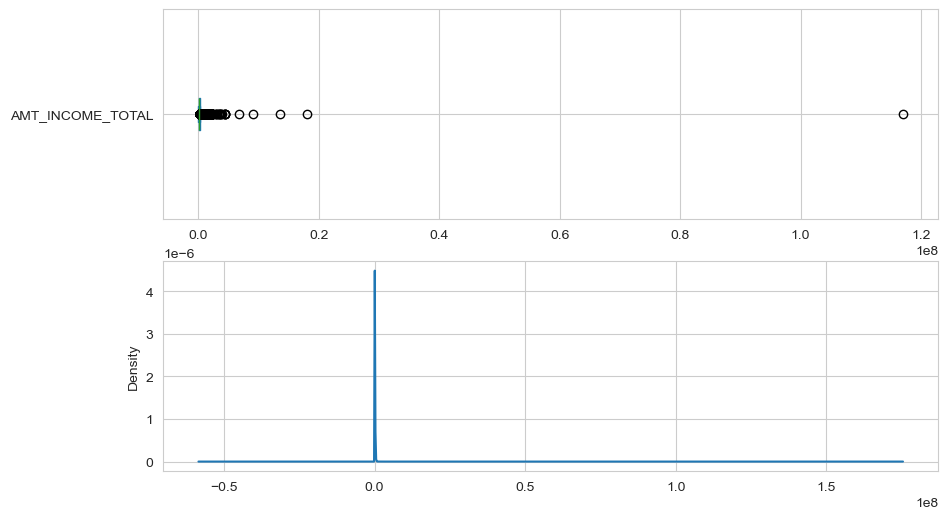

-------------------- AMT_CREDIT ---------------------

lower outlier: 0        upper outlier: 6562



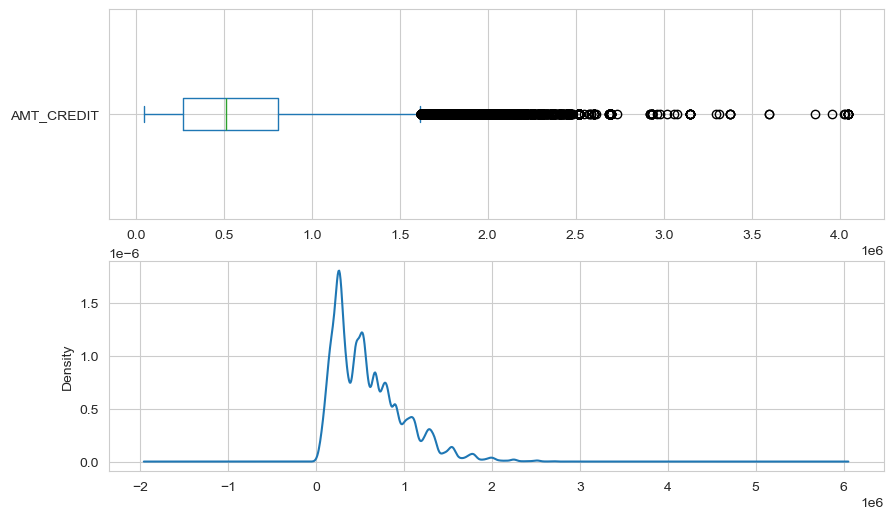

-------------------- AMT_ANNUITY ---------------------

lower outlier: 0        upper outlier: 7504



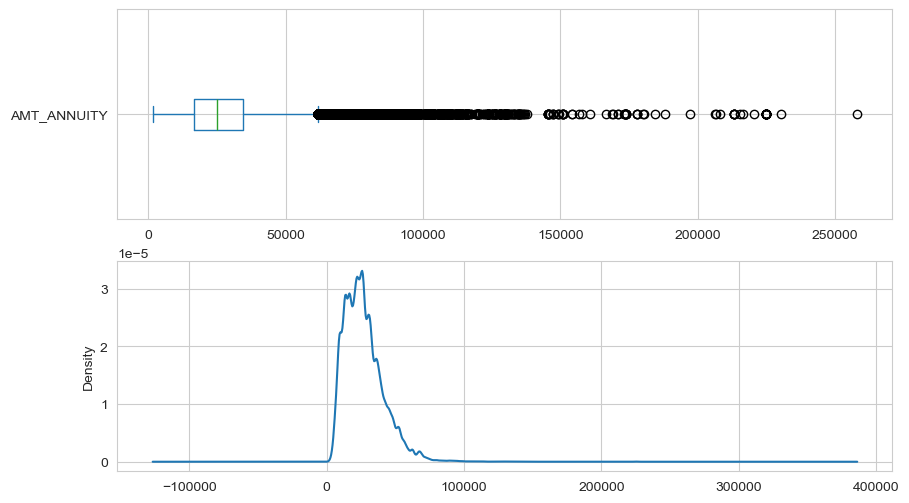

-------------------- AMT_GOODS_PRICE ---------------------

lower outlier: 0        upper outlier: 14728



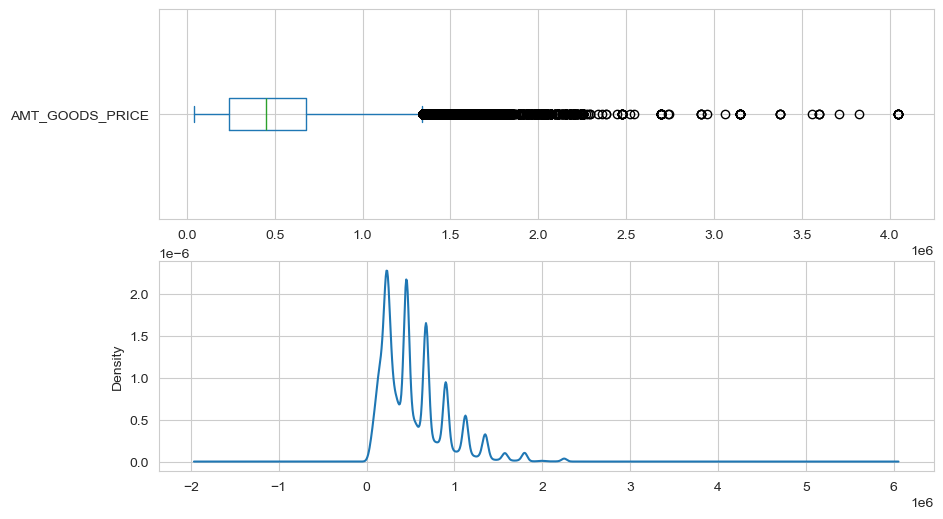

-------------------- REGION_POPULATION_RELATIVE ---------------------

lower outlier: 0        upper outlier: 8412



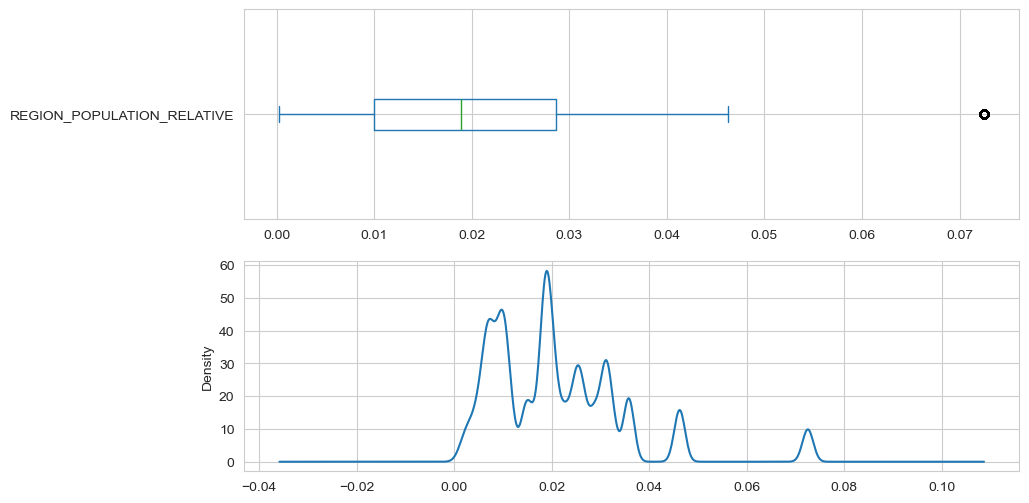

-------------------- EXT_SOURCE_2 ---------------------

lower outlier: 0        upper outlier: 0



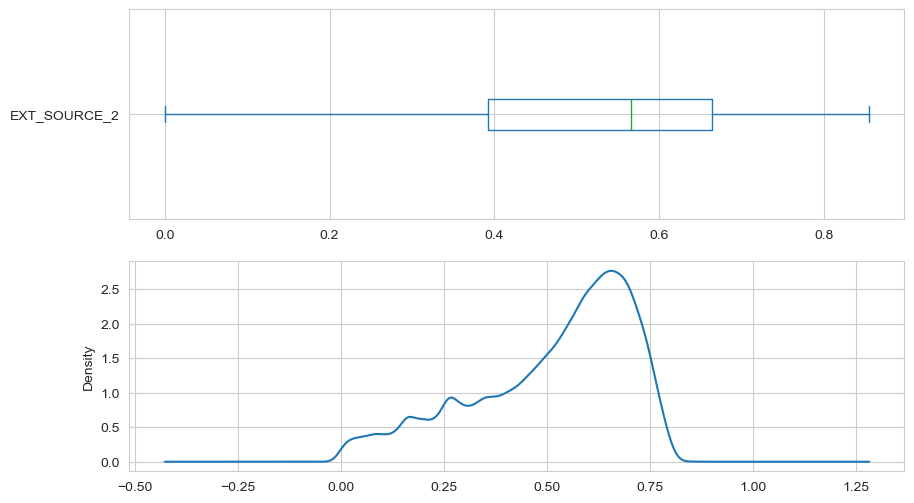

-------------------- EXT_SOURCE_3 ---------------------

lower outlier: 0        upper outlier: 0



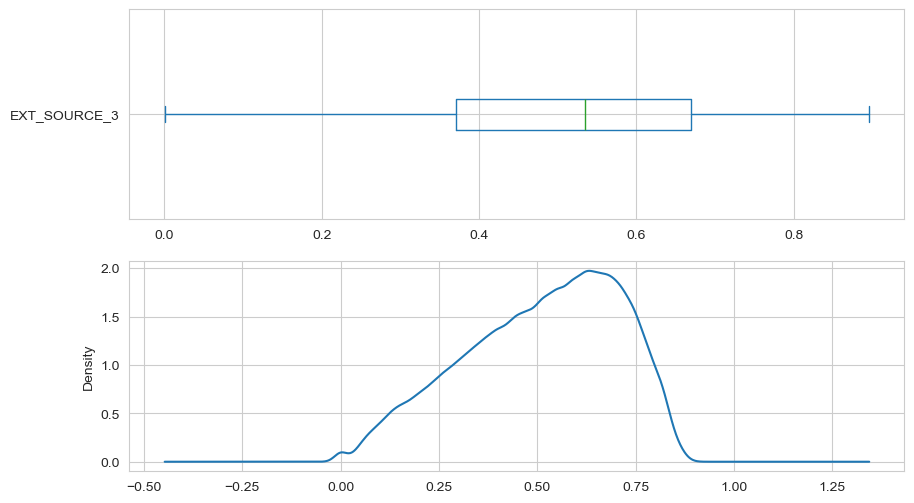

-------------------- OBS_30_CNT_SOCIAL_CIRCLE ---------------------

lower outlier: 0        upper outlier: 19971



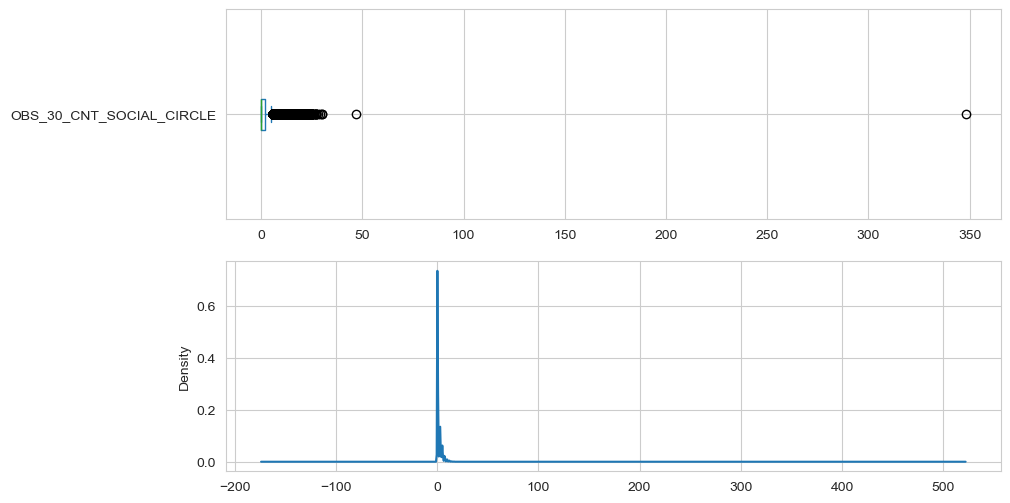

-------------------- DEF_30_CNT_SOCIAL_CIRCLE ---------------------

lower outlier: 0        upper outlier: 35166



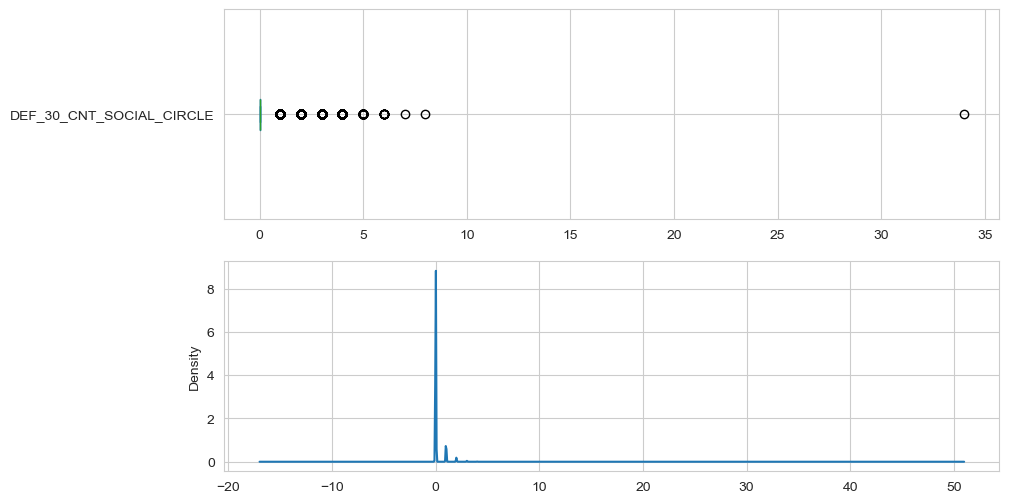

-------------------- OBS_60_CNT_SOCIAL_CIRCLE ---------------------

lower outlier: 0        upper outlier: 19564



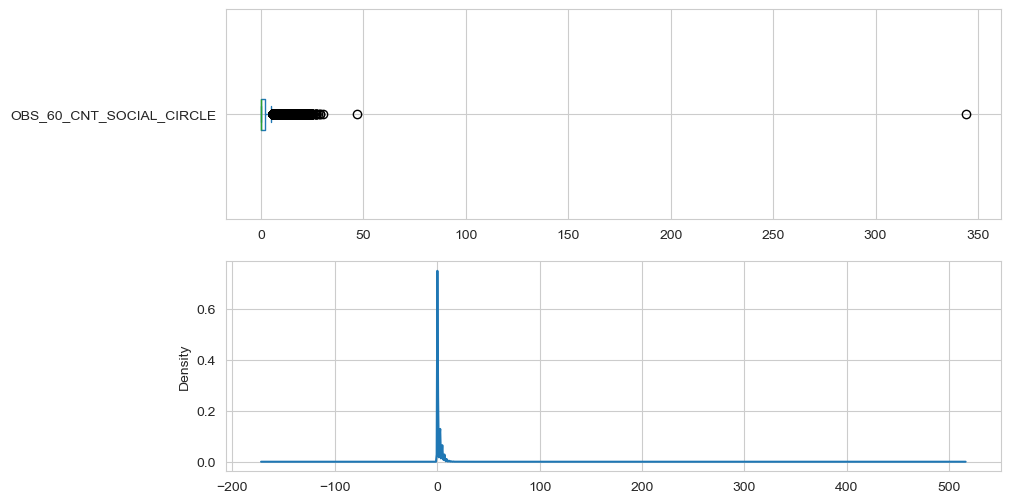

-------------------- DEF_60_CNT_SOCIAL_CIRCLE ---------------------

lower outlier: 0        upper outlier: 25769



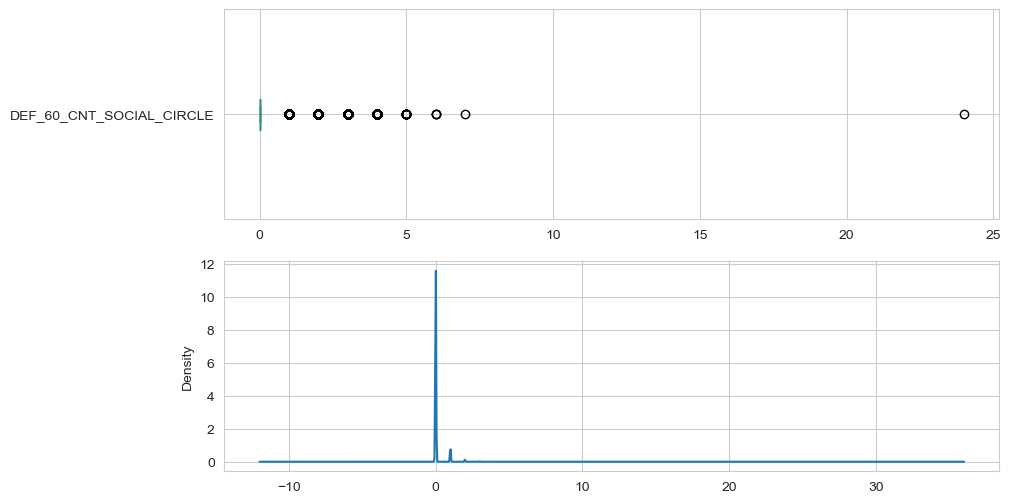

-------------------- AMT_REQ_CREDIT_BUREAU_HOUR ---------------------

lower outlier: 0        upper outlier: 1626



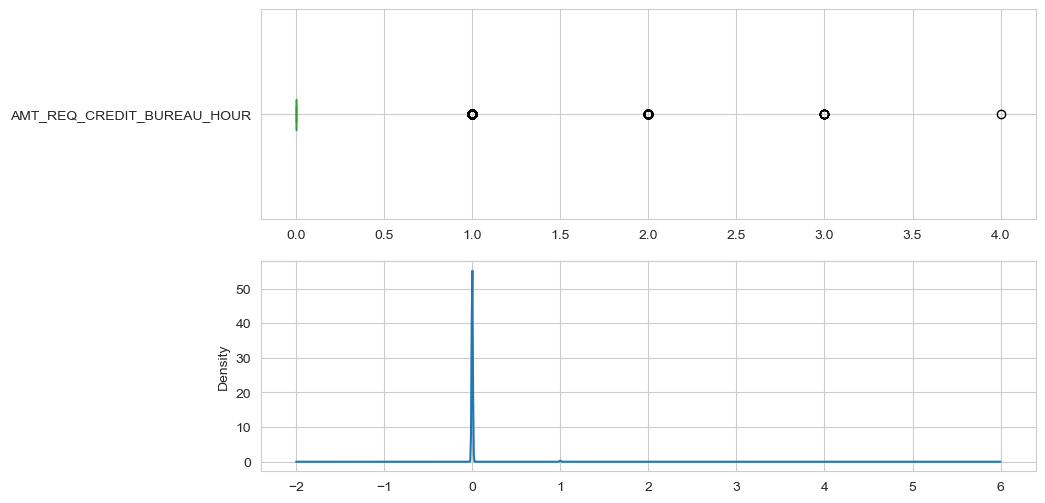

-------------------- AMT_REQ_CREDIT_BUREAU_DAY ---------------------

lower outlier: 0        upper outlier: 1489



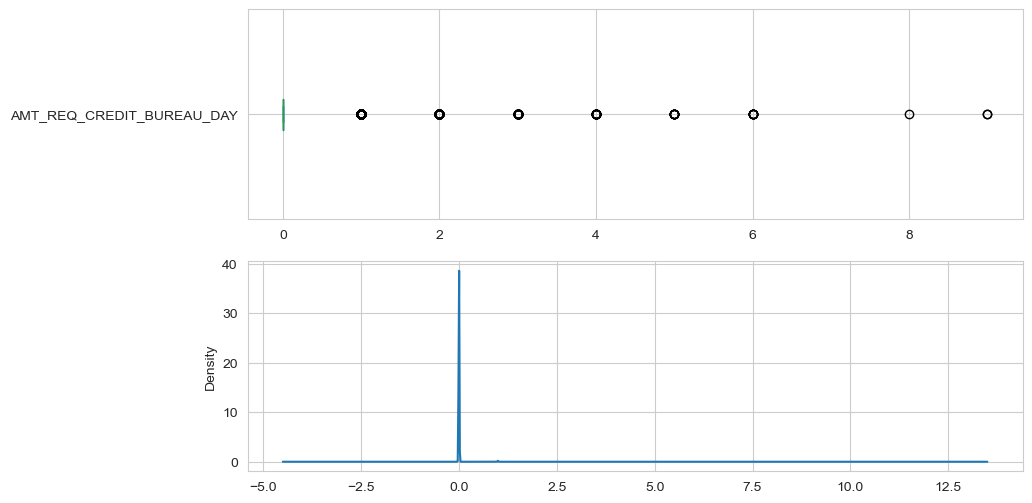

-------------------- AMT_REQ_CREDIT_BUREAU_WEEK ---------------------

lower outlier: 0        upper outlier: 8536



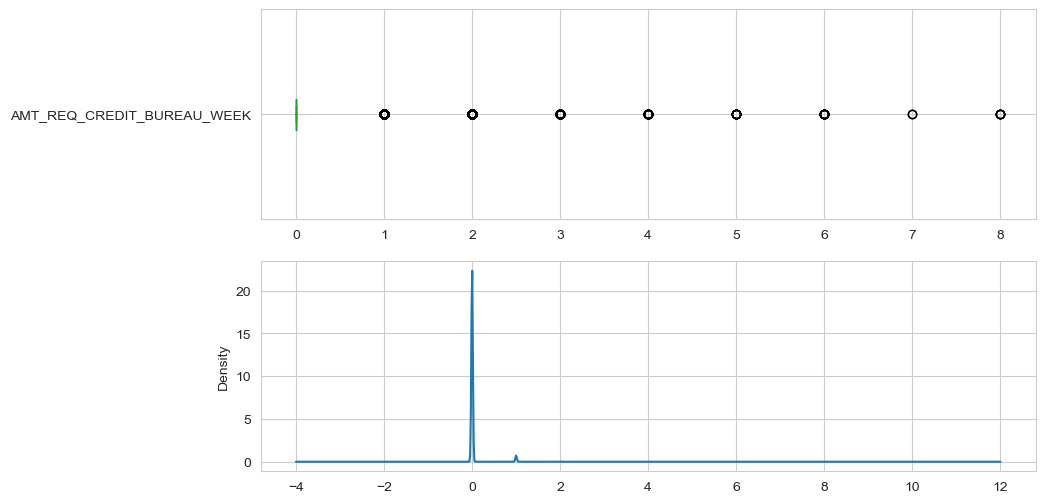

-------------------- AMT_REQ_CREDIT_BUREAU_MON ---------------------

lower outlier: 0        upper outlier: 43759



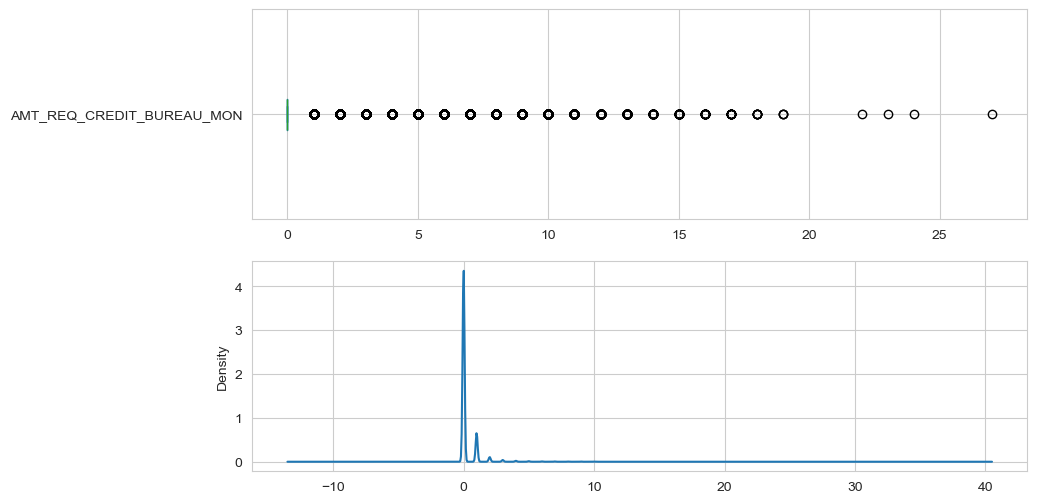

-------------------- AMT_REQ_CREDIT_BUREAU_QRT ---------------------

lower outlier: 0        upper outlier: 50575



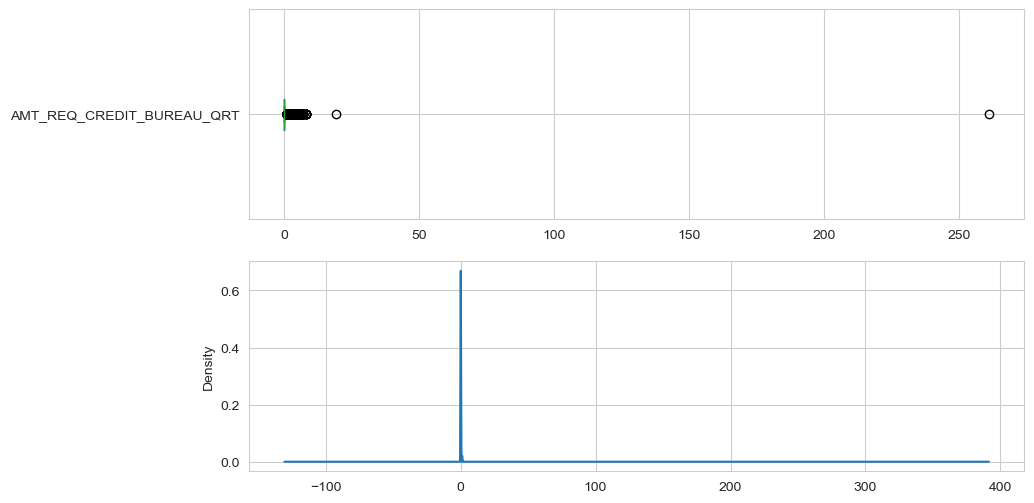

-------------------- AMT_REQ_CREDIT_BUREAU_YEAR ---------------------

lower outlier: 0        upper outlier: 3364



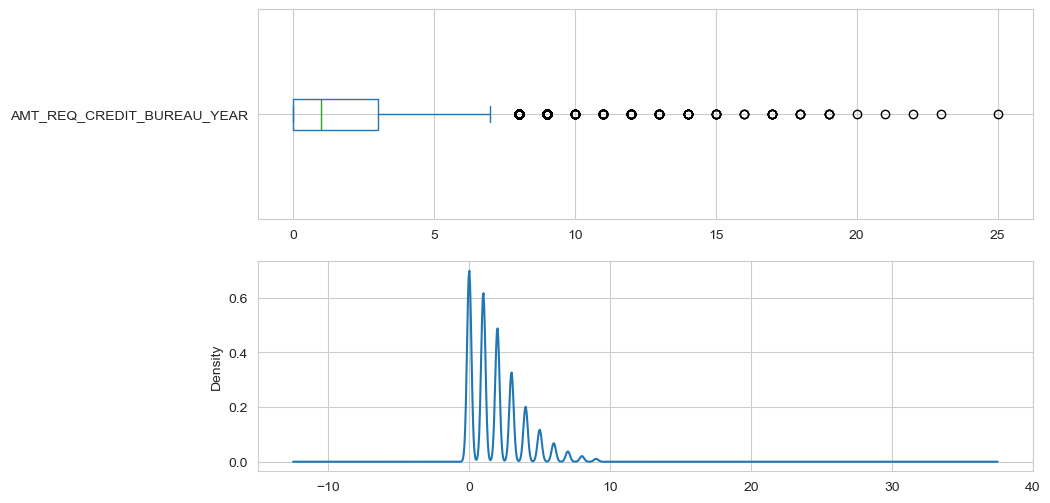

In [68]:
for i in range(len(continuous_col)):
    preprocess(continuous[continuous_col], continuous_col[i])

In [69]:
# fill null cho các continuous feature 
print('Columns that have missing value:')
continuous_is_null = continuous.isnull().sum() != 0
continuous_feature_list = continuous.columns[continuous_is_null].tolist()
print("Train: \n",continuous_feature_list)


continuous_is_null_test = continuous_test.isnull().sum() != 0
continuous_feature_test_list = continuous_test.columns[continuous_is_null_test].tolist()
print("Test: \n",continuous_feature_test_list)

Columns that have missing value:
Train: 
 ['AMT_ANNUITY', 'AMT_GOODS_PRICE', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR']
Test: 
 ['AMT_ANNUITY', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR']


In [70]:
print("Train set:\n")
for i in range(len(continuous_feature_list)):
    replace_mean(continuous, continuous_feature_list[i])

print("----------------------------------")
print("Test set:\n")
for i in range(len(continuous_feature_test_list)):
    replace_mean(continuous_test, continuous_feature_test_list[i])

Train set:

NaN in AMT_ANNUITY replaced with 27108.57
NaN in AMT_GOODS_PRICE replaced with 538396.21
NaN in EXT_SOURCE_2 replaced with 0.51
NaN in EXT_SOURCE_3 replaced with 0.51
NaN in OBS_30_CNT_SOCIAL_CIRCLE replaced with 1.42
NaN in DEF_30_CNT_SOCIAL_CIRCLE replaced with 0.14
NaN in OBS_60_CNT_SOCIAL_CIRCLE replaced with 1.41
NaN in DEF_60_CNT_SOCIAL_CIRCLE replaced with 0.1
NaN in AMT_REQ_CREDIT_BUREAU_HOUR replaced with 0.01
NaN in AMT_REQ_CREDIT_BUREAU_DAY replaced with 0.01
NaN in AMT_REQ_CREDIT_BUREAU_WEEK replaced with 0.03
NaN in AMT_REQ_CREDIT_BUREAU_MON replaced with 0.27
NaN in AMT_REQ_CREDIT_BUREAU_QRT replaced with 0.27
NaN in AMT_REQ_CREDIT_BUREAU_YEAR replaced with 1.9
----------------------------------
Test set:

NaN in AMT_ANNUITY replaced with 29426.24
NaN in EXT_SOURCE_2 replaced with 0.52
NaN in EXT_SOURCE_3 replaced with 0.5
NaN in OBS_30_CNT_SOCIAL_CIRCLE replaced with 1.45
NaN in DEF_30_CNT_SOCIAL_CIRCLE replaced with 0.14
NaN in OBS_60_CNT_SOCIAL_CIRCLE repla

In [71]:
# Fill null cho các discrete feature
print('Columns that have missing value:')

# Train
discrete_is_null = discrete.isnull().sum() != 0
discrete_feature_list = discrete.columns[discrete_is_null].tolist()
print("Train: \n", discrete_feature_list)

# Test
discrete_is_null_test = discrete_test.isnull().sum() != 0
discrete_feature_test_list = discrete_test.columns[discrete_is_null_test].tolist()
print("Test: \n", discrete_feature_test_list)

Columns that have missing value:
Train: 
 ['CNT_FAM_MEMBERS', 'DAYS_LAST_PHONE_CHANGE']
Test: 
 []


In [72]:
for col in discrete_feature_list:
    discrete[col] = discrete[col].fillna(discrete[col].median())
    discrete_test[col] = discrete_test[col].fillna(discrete_test[col].median())

In [73]:
continuous.isnull().sum().sort_values(ascending = False)

AMT_INCOME_TOTAL              0
OBS_60_CNT_SOCIAL_CIRCLE      0
AMT_REQ_CREDIT_BUREAU_QRT     0
AMT_REQ_CREDIT_BUREAU_MON     0
AMT_REQ_CREDIT_BUREAU_WEEK    0
AMT_REQ_CREDIT_BUREAU_DAY     0
AMT_REQ_CREDIT_BUREAU_HOUR    0
DEF_60_CNT_SOCIAL_CIRCLE      0
DEF_30_CNT_SOCIAL_CIRCLE      0
AMT_CREDIT                    0
OBS_30_CNT_SOCIAL_CIRCLE      0
EXT_SOURCE_3                  0
EXT_SOURCE_2                  0
REGION_POPULATION_RELATIVE    0
AMT_GOODS_PRICE               0
AMT_ANNUITY                   0
AMT_REQ_CREDIT_BUREAU_YEAR    0
dtype: int64

In [74]:
continuous_test.isnull().sum().sort_values(ascending = False)

AMT_INCOME_TOTAL              0
OBS_60_CNT_SOCIAL_CIRCLE      0
AMT_REQ_CREDIT_BUREAU_QRT     0
AMT_REQ_CREDIT_BUREAU_MON     0
AMT_REQ_CREDIT_BUREAU_WEEK    0
AMT_REQ_CREDIT_BUREAU_DAY     0
AMT_REQ_CREDIT_BUREAU_HOUR    0
DEF_60_CNT_SOCIAL_CIRCLE      0
DEF_30_CNT_SOCIAL_CIRCLE      0
AMT_CREDIT                    0
OBS_30_CNT_SOCIAL_CIRCLE      0
EXT_SOURCE_3                  0
EXT_SOURCE_2                  0
REGION_POPULATION_RELATIVE    0
AMT_GOODS_PRICE               0
AMT_ANNUITY                   0
AMT_REQ_CREDIT_BUREAU_YEAR    0
dtype: int64

In [75]:
numeric[continuous_col] = continuous[continuous_col]
numeric_test[continuous_col] = continuous_test[continuous_col]

numeric[discrete_col] = discrete[discrete_col]
numeric_test[discrete_col] = discrete_test[discrete_col]

##### Outlier

In [76]:
col_names = numeric.columns
col_names_test = numeric_test.columns

In [77]:
print('Outliers in dataset:')
print("Train set:\n")
for i in range(len(col_names)):
    print("{}: {}".format(col_names[i],(outlier_detect(numeric,col_names[i]).shape[0])))
    
print("\n\n-----------------------------------------\n")
print("Test set:\n")
for i in range(len(col_names_test)):
    print("{}: {}".format(col_names_test[i],(outlier_detect(numeric_test,col_names_test[i]).shape[0])))

Outliers in dataset:
Train set:

SK_ID_CURR: 0
TARGET: 24825
CNT_CHILDREN: 4272
AMT_INCOME_TOTAL: 14035
AMT_CREDIT: 6562
AMT_ANNUITY: 7504
AMT_GOODS_PRICE: 14728
REGION_POPULATION_RELATIVE: 8412
DAYS_BIRTH: 0
DAYS_EMPLOYED: 72217
DAYS_REGISTRATION: 659
DAYS_ID_PUBLISH: 0
CNT_FAM_MEMBERS: 4007
REGION_RATING_CLIENT: 80527
REGION_RATING_CLIENT_W_CITY: 78027
HOUR_APPR_PROCESS_START: 2257
EXT_SOURCE_2: 0
EXT_SOURCE_3: 0
OBS_30_CNT_SOCIAL_CIRCLE: 19971
DEF_30_CNT_SOCIAL_CIRCLE: 36187
OBS_60_CNT_SOCIAL_CIRCLE: 19564
DEF_60_CNT_SOCIAL_CIRCLE: 26790
DAYS_LAST_PHONE_CHANGE: 435
AMT_REQ_CREDIT_BUREAU_HOUR: 43145
AMT_REQ_CREDIT_BUREAU_DAY: 43008
AMT_REQ_CREDIT_BUREAU_WEEK: 50055
AMT_REQ_CREDIT_BUREAU_MON: 85278
AMT_REQ_CREDIT_BUREAU_QRT: 92094
AMT_REQ_CREDIT_BUREAU_YEAR: 3364


-----------------------------------------

Test set:

SK_ID_CURR: 0
CNT_CHILDREN: 606
AMT_INCOME_TOTAL: 2722
AMT_CREDIT: 1126
AMT_ANNUITY: 1915
AMT_GOODS_PRICE: 2018
REGION_POPULATION_RELATIVE: 1565
DAYS_BIRTH: 0
DAYS_EMPLO

In [78]:
outlier = []
for i in range(len(numeric_feature_list)):
    if outlier_detect(numeric[numeric_feature_list],numeric_feature_list[i]).shape[0] !=0:
        outlier.append(numeric_feature_list[i])

outlier_test = []
for i in range(len(numeric_feature_test_list)):
    if outlier_detect(numeric_test[numeric_feature_test_list],numeric_feature_test_list[i]).shape[0] !=0:
        outlier_test.append(numeric_feature_test_list[i])

In [79]:
# without TARGET field
col_names = outlier_test

In [80]:
# upper outlier 
print("Train:\n")
for i in range(len(col_names)):
    print("{}: {}".format(col_names[i],(upper_outlier(numeric,col_names[i]).shape[0])))
    
print("\n\n---------------------------------------\n")
print("Test:\n")
for i in range(len(col_names)):
    print("{}: {}".format(col_names[i],(upper_outlier(numeric_test,col_names[i]).shape[0])))

Train:

CNT_CHILDREN: 4272
AMT_INCOME_TOTAL: 14035
AMT_CREDIT: 6562
AMT_ANNUITY: 7504
AMT_GOODS_PRICE: 14728
REGION_POPULATION_RELATIVE: 8412
DAYS_EMPLOYED: 55374
DAYS_REGISTRATION: 0
CNT_FAM_MEMBERS: 4007
REGION_RATING_CLIENT: 48330
REGION_RATING_CLIENT_W_CITY: 43860
HOUR_APPR_PROCESS_START: 596
OBS_30_CNT_SOCIAL_CIRCLE: 19971
DEF_30_CNT_SOCIAL_CIRCLE: 36187
OBS_60_CNT_SOCIAL_CIRCLE: 19564
DEF_60_CNT_SOCIAL_CIRCLE: 26790
DAYS_LAST_PHONE_CHANGE: 0
AMT_REQ_CREDIT_BUREAU_HOUR: 43145
AMT_REQ_CREDIT_BUREAU_DAY: 43008
AMT_REQ_CREDIT_BUREAU_WEEK: 50055
AMT_REQ_CREDIT_BUREAU_MON: 85278
AMT_REQ_CREDIT_BUREAU_QRT: 92094
AMT_REQ_CREDIT_BUREAU_YEAR: 3364


---------------------------------------

Test:

CNT_CHILDREN: 606
AMT_INCOME_TOTAL: 2722
AMT_CREDIT: 1126
AMT_ANNUITY: 1915
AMT_GOODS_PRICE: 2018
REGION_POPULATION_RELATIVE: 1565
DAYS_EMPLOYED: 9274
DAYS_REGISTRATION: 0
CNT_FAM_MEMBERS: 576
REGION_RATING_CLIENT: 7624
REGION_RATING_CLIENT_W_CITY: 6792
HOUR_APPR_PROCESS_START: 101
OBS_30_CNT_SOCI

In [81]:
for i in range(len(col_names)):
    replace_upper(numeric, col_names[i])   
    
for i in range(len(col_names)):
    replace_upper(numeric_test, col_names[i]) 

In [82]:
print("Train:\n")
for i in range(len(col_names)):
    print("{}: {}".format(col_names[i],(upper_outlier(numeric,col_names[i]).shape[0])))
    
print("\n\n------------------------------------\n")
print("Test:\n")
for i in range(len(col_names)):
    print("{}: {}".format(col_names[i],(upper_outlier(numeric_test,col_names[i]).shape[0])))

Train:

CNT_CHILDREN: 0
AMT_INCOME_TOTAL: 0
AMT_CREDIT: 0
AMT_ANNUITY: 0
AMT_GOODS_PRICE: 0
REGION_POPULATION_RELATIVE: 0
DAYS_EMPLOYED: 0
DAYS_REGISTRATION: 0
CNT_FAM_MEMBERS: 0
REGION_RATING_CLIENT: 0
REGION_RATING_CLIENT_W_CITY: 0
HOUR_APPR_PROCESS_START: 0
OBS_30_CNT_SOCIAL_CIRCLE: 0
DEF_30_CNT_SOCIAL_CIRCLE: 0
OBS_60_CNT_SOCIAL_CIRCLE: 0
DEF_60_CNT_SOCIAL_CIRCLE: 0
DAYS_LAST_PHONE_CHANGE: 0
AMT_REQ_CREDIT_BUREAU_HOUR: 0
AMT_REQ_CREDIT_BUREAU_DAY: 0
AMT_REQ_CREDIT_BUREAU_WEEK: 0
AMT_REQ_CREDIT_BUREAU_MON: 0
AMT_REQ_CREDIT_BUREAU_QRT: 0
AMT_REQ_CREDIT_BUREAU_YEAR: 0


------------------------------------

Test:

CNT_CHILDREN: 0
AMT_INCOME_TOTAL: 0
AMT_CREDIT: 0
AMT_ANNUITY: 0
AMT_GOODS_PRICE: 0
REGION_POPULATION_RELATIVE: 0
DAYS_EMPLOYED: 0
DAYS_REGISTRATION: 0
CNT_FAM_MEMBERS: 0
REGION_RATING_CLIENT: 0
REGION_RATING_CLIENT_W_CITY: 0
HOUR_APPR_PROCESS_START: 0
OBS_30_CNT_SOCIAL_CIRCLE: 0
DEF_30_CNT_SOCIAL_CIRCLE: 0
OBS_60_CNT_SOCIAL_CIRCLE: 0
DEF_60_CNT_SOCIAL_CIRCLE: 0
DAYS_LAST_PH

In [83]:
print("Train:\n")
for i in range(len(col_names)):
    print("{}: {}".format(col_names[i],(lower_outlier(numeric,col_names[i]).shape[0])))
    
print("\n\n****************************************\n")
print("Test:\n")
for i in range(len(col_names)):
    print("{}: {}".format(col_names[i],(lower_outlier(numeric_test,col_names[i]).shape[0])))

Train:

CNT_CHILDREN: 0
AMT_INCOME_TOTAL: 0
AMT_CREDIT: 0
AMT_ANNUITY: 0
AMT_GOODS_PRICE: 0
REGION_POPULATION_RELATIVE: 0
DAYS_EMPLOYED: 16843
DAYS_REGISTRATION: 659
CNT_FAM_MEMBERS: 0
REGION_RATING_CLIENT: 32197
REGION_RATING_CLIENT_W_CITY: 34167
HOUR_APPR_PROCESS_START: 1661
OBS_30_CNT_SOCIAL_CIRCLE: 0
DEF_30_CNT_SOCIAL_CIRCLE: 0
OBS_60_CNT_SOCIAL_CIRCLE: 0
DEF_60_CNT_SOCIAL_CIRCLE: 0
DAYS_LAST_PHONE_CHANGE: 435
AMT_REQ_CREDIT_BUREAU_HOUR: 0
AMT_REQ_CREDIT_BUREAU_DAY: 0
AMT_REQ_CREDIT_BUREAU_WEEK: 0
AMT_REQ_CREDIT_BUREAU_MON: 0
AMT_REQ_CREDIT_BUREAU_QRT: 0
AMT_REQ_CREDIT_BUREAU_YEAR: 0


****************************************

Test:

CNT_CHILDREN: 0
AMT_INCOME_TOTAL: 0
AMT_CREDIT: 0
AMT_ANNUITY: 0
AMT_GOODS_PRICE: 0
REGION_POPULATION_RELATIVE: 0
DAYS_EMPLOYED: 2629
DAYS_REGISTRATION: 116
CNT_FAM_MEMBERS: 0
REGION_RATING_CLIENT: 5764
REGION_RATING_CLIENT_W_CITY: 6176
HOUR_APPR_PROCESS_START: 306
OBS_30_CNT_SOCIAL_CIRCLE: 0
DEF_30_CNT_SOCIAL_CIRCLE: 0
OBS_60_CNT_SOCIAL_CIRCLE: 0
DEF_

In [84]:
for i in range(len(col_names)):
    replace_lower(numeric, col_names[i])
    
# #--------------------------------------------------
for i in range(len(col_names)):
    replace_lower(numeric_test, col_names[i])

In [85]:
print("Train:\n")
for i in range(len(col_names)):
    print("{}: {}".format(col_names[i],(lower_outlier(numeric,col_names[i]).shape[0])))
    
print("\n\n---------------------------------------\n")
print("Test:\n")
for i in range(len(col_names)):
    print("{}: {}".format(col_names[i],(lower_outlier(numeric_test,col_names[i]).shape[0])))

Train:

CNT_CHILDREN: 0
AMT_INCOME_TOTAL: 0
AMT_CREDIT: 0
AMT_ANNUITY: 0
AMT_GOODS_PRICE: 0
REGION_POPULATION_RELATIVE: 0
DAYS_EMPLOYED: 0
DAYS_REGISTRATION: 0
CNT_FAM_MEMBERS: 0
REGION_RATING_CLIENT: 0
REGION_RATING_CLIENT_W_CITY: 0
HOUR_APPR_PROCESS_START: 0
OBS_30_CNT_SOCIAL_CIRCLE: 0
DEF_30_CNT_SOCIAL_CIRCLE: 0
OBS_60_CNT_SOCIAL_CIRCLE: 0
DEF_60_CNT_SOCIAL_CIRCLE: 0
DAYS_LAST_PHONE_CHANGE: 0
AMT_REQ_CREDIT_BUREAU_HOUR: 0
AMT_REQ_CREDIT_BUREAU_DAY: 0
AMT_REQ_CREDIT_BUREAU_WEEK: 0
AMT_REQ_CREDIT_BUREAU_MON: 0
AMT_REQ_CREDIT_BUREAU_QRT: 0
AMT_REQ_CREDIT_BUREAU_YEAR: 0


---------------------------------------

Test:

CNT_CHILDREN: 0
AMT_INCOME_TOTAL: 0
AMT_CREDIT: 0
AMT_ANNUITY: 0
AMT_GOODS_PRICE: 0
REGION_POPULATION_RELATIVE: 0
DAYS_EMPLOYED: 0
DAYS_REGISTRATION: 0
CNT_FAM_MEMBERS: 0
REGION_RATING_CLIENT: 0
REGION_RATING_CLIENT_W_CITY: 0
HOUR_APPR_PROCESS_START: 0
OBS_30_CNT_SOCIAL_CIRCLE: 0
DEF_30_CNT_SOCIAL_CIRCLE: 0
OBS_60_CNT_SOCIAL_CIRCLE: 0
DEF_60_CNT_SOCIAL_CIRCLE: 0
DAYS_LAST

In [86]:
categorical.drop(['ORGANIZATION_TYPE'], axis=1, inplace=True)
categorical_test.drop(['ORGANIZATION_TYPE'], axis=1, inplace=True)

In [87]:
le = LabelEncoder() 
categorical = categorical.apply(lambda col_names_cat: le.fit_transform(col_names_cat)) 
categorical_test = categorical_test.apply(lambda col_names_cat: le.fit_transform(col_names_cat)) 
categorical.head()

,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,...,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21
0,0,1,0,1,6,7,4,3,1,8,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,1,4,1,1,1,3,...,0,0,0,0,0,0,0,0,0,0
2,1,1,1,1,6,7,4,3,1,8,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,1,6,7,4,0,1,8,...,0,0,0,0,0,0,0,0,0,0
4,0,1,0,1,6,7,4,3,1,3,...,0,0,0,0,0,0,0,0,0,0


In [88]:
print("Train: ",categorical.shape)
print("Test: ",categorical_test.shape)

Train:  (307511, 43)
Test:  (48744, 43)


In [89]:
col_names_cat = categorical.columns
col_names = numeric_test.columns

In [90]:
train_new[col_names_cat] = categorical[col_names_cat]
train_new[col_names] = numeric[col_names]

test_new[col_names] = numeric_test[col_names]
test_new[col_names_cat] = categorical_test[col_names_cat]

In [91]:
train_new.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE',
       'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
       'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'FLAG_MOBIL',
       'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE',
       'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS',
       'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY',
       'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START',
       'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION',
       'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY',
       'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY',
       'ORGANIZATION_TYPE', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
       'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_C

In [92]:
train_new.drop(['ORGANIZATION_TYPE'], axis=1, inplace=True)
test_new.drop(['ORGANIZATION_TYPE'], axis=1, inplace=True)

In [93]:
print("Train: ",train_new.loc[train.duplicated()].shape)
print("Test: ",test_new.loc[test.duplicated()].shape)

Train:  (0, 72)
Test:  (0, 71)


### Normalization

In [94]:
x_train = train_new.drop(["TARGET", "SK_ID_CURR"], axis = 1)
y_train = train_new['TARGET']

In [95]:
scaler=MinMaxScaler()
col = ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR',
       'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
       'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE',
       'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
       'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
       'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'FLAG_MOBIL', 'FLAG_EMP_PHONE',
       'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL',
       'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT',
       'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START',
       'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION',
       'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION',
       'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY',
       'LIVE_CITY_NOT_WORK_CITY', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
       'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE',
       'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE',
       'DAYS_LAST_PHONE_CHANGE', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3',
       'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6',
       'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9',
       'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12',
       'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15',
       'FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18',
       'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21',
       'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY',
       'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON',
       'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR']

x_train[col] = pd.DataFrame(scaler.fit_transform(x_train[col]))
test_new[col] = pd.DataFrame(scaler.transform(test_new[col]))

In [96]:
from sklearn.model_selection import StratifiedKFold, train_test_split

# 2. Split into X/y and train/validation
X_tr, X_val, y_tr, y_val = train_test_split(
    x_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

In [97]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
# 3. Feature selection: univariate + model-based intersection
sel_uni = SelectKBest(mutual_info_classif, k=30).fit(X_tr, y_tr)
feats_uni = X_tr.columns[sel_uni.get_support()]
model_lgb = LGBMClassifier(random_state=42).fit(X_tr, y_tr)
imp = pd.Series(model_lgb.feature_importances_, index=X_tr.columns).sort_values(ascending=False)
feats_lgb = imp.head(40).index
final_features = list(set(feats_uni) & set(feats_lgb))

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.025957 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2942
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 57
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482


In [98]:
# 4. Define FeatureSelector transformer
from sklearn.base import BaseEstimator, TransformerMixin
class FeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, features): self.features = features
    def fit(self, X, y=None): return self
    def transform(self, X): return X[self.features]

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from lightgbm import LGBMClassifier

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipe_lgb = Pipeline([
    ('select', FeatureSelector(final_features)),
    ('clf', LGBMClassifier(random_state=42, n_estimators=300))
])

param_dist = {
    'clf__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'clf__num_leaves': [31, 50, 100, 200],
    'clf__max_depth': [-1, 5, 10, 20],
    'clf__min_child_samples': [10, 20, 50, 100],
    'clf__feature_fraction': [0.6, 0.8, 1.0],
    'clf__bagging_fraction': [0.6, 0.8, 1.0],
    'clf__lambda_l1': [0, 0.1, 1, 5],
    'clf__lambda_l2': [0, 0.1, 1, 5]
}

rs_lgb = RandomizedSearchCV(
    estimator=pipe_lgb,
    param_distributions=param_dist,
    n_iter=30,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rs_lgb.fit(X_tr, y_tr)
best_lgb = rs_lgb.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] lambda_l1 is set=5, reg_alpha=0.0 will be ignored. Current value: lambda_l1=5
[LightGBM] [Warning] lambda_l2 is set=1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] lambda_l1 is set=5, reg_alpha=0.0 will be ignored. Current value: lambda_l1=5
[LightGBM] [Warning] lambda_l2 is set=1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Number of positive: 19860, number of neg

In [101]:
# 6. Tune Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV


pipe_lr = Pipeline([
    ('select', FeatureSelector(final_features)),
    ('clf', LogisticRegression(class_weight='balanced', solver='saga', max_iter=2000, random_state=42))
])
param_lr = {'clf__C': [0.001, 0.01, 0.1, 1, 10], 'clf__penalty': ['l1','l2']}
gs_lr = GridSearchCV(pipe_lr, param_lr, cv=skf, scoring='roc_auc', n_jobs=-1)
gs_lr.fit(X_tr, y_tr)
best_lr = gs_lr.best_estimator_

In [102]:
# 7. Train XGBoost
xgb = XGBClassifier(learning_rate=0.03, max_depth=6, n_estimators=500, eval_metric='auc', use_label_encoder=False, random_state=42)
xgb.fit(X_tr[final_features], y_tr)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [103]:
# 8. Build stacking ensemble
from sklearn.ensemble import StackingClassifier

stack = StackingClassifier(
    estimators=[('lgb', best_lgb), ('lr', best_lr), ('xgb', Pipeline([('select', FeatureSelector(final_features)), ('clf', xgb)]))],
    final_estimator=LogisticRegression(),
    cv=skf, n_jobs=-1
)
stack.fit(X_tr, y_tr)

StackingClassifier(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimators=[('lgb',
                                Pipeline(steps=[('select',
                                                 FeatureSelector(features=['OCCUPATION_TYPE',
                                                                           'NAME_EDUCATION_TYPE',
                                                                           'EXT_SOURCE_3',
                                                                           'NAME_FAMILY_STATUS',
                                                                           'FLAG_OWN_CAR',
                                                                           'NAME_HOUSING_TYPE',
                                                                           'CNT_CHILDREN',
                                                                           'FLAG_DOCUMENT_3',
                                                                           'FLAG_PHONE',
                                                                           'EXT_SOURCE_2',
                                                                           'AMT_REQ_CREDIT_BUREAU_YEAR'...
                                                               importance_type=None,
                                                               interaction_constraints=None,
                                                               learning_rate=0.03,
                                                               max_bin=None,
                                                               max_cat_threshold=None,
                                                               max_cat_to_onehot=None,
                                                               max_delta_step=None,
                                                               max_depth=6,
                                                               max_leaves=None,
                                                               min_child_weight=None,
                                                               missing=nan,
                                                               monotone_constraints=None,
                                                               multi_strategy=None,
                                                               n_estimators=500,
                                                               n_jobs=None,
                                                               num_parallel_tree=None, ...))]))],
                   final_estimator=LogisticRegression(), n_jobs=-1)

In [104]:
# 9. Threshold calibration on hold-out
probs_stack = stack.predict_proba(X_val[final_features])[:,1]
fpr, tpr, thr = roc_curve(y_val, probs_stack)
opt_thr = thr[np.where(fpr <= 0.10)[0].max()]

[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] lambda_l1 is set=5, reg_alpha=0.0 will be ignored. Current value: lambda_l1=5
[LightGBM] [Warning] lambda_l2 is set=1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8


In [105]:
# 10. Final evaluation
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, confusion_matrix

auc_val = roc_auc_score(y_val, probs_stack)
precision, recall, _ = precision_recall_curve(y_val, probs_stack)
pr_auc = auc(recall, precision)
cm = confusion_matrix(y_val, (probs_stack >= opt_thr).astype(int))

In [109]:
print(f'auc_val: {auc_val}')
print(f'precision: {precision}')
print(f'recall: {recall}')
print(f'pr_auc: {pr_auc}')
print(f'cm: {cm}')

auc_val: 0.7451568421733983
precision: [0.08072777 0.08072908 0.08073039 ... 1.         1.         1.        ]
recall: [1.00000000e+00 1.00000000e+00 1.00000000e+00 ... 4.02819738e-04
 2.01409869e-04 0.00000000e+00]
pr_auc: 0.2392179923770444
cm: [[50914  5624]
 [ 3096  1869]]


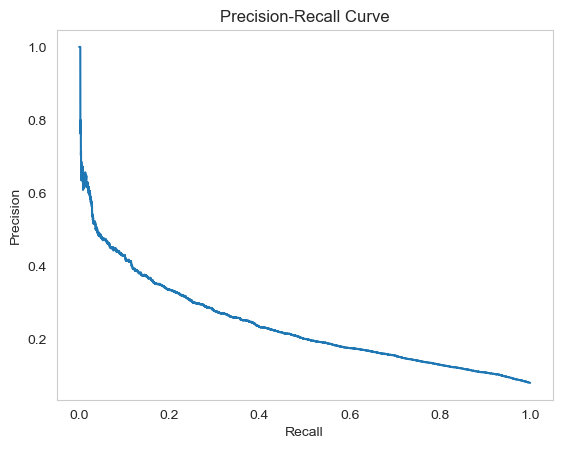

In [110]:
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid()
plt.show()

In [111]:
X_test = test_new[final_features]
probs_test = stack.predict_proba(X_test)[:,1]
pred_test = (probs_test >= 0.1485).astype(int)


[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] lambda_l1 is set=5, reg_alpha=0.0 will be ignored. Current value: lambda_l1=5
[LightGBM] [Warning] lambda_l2 is set=1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
